# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  5716k      0 --:--:--  0:02:37 --:--:-- 5921k


In [2]:
!rm SUSY.csv

In [3]:
!gunzip SUSY.csv.gz

In [4]:
ls -lh

total 5157296
-rw-r--r--@ 1 samipbajgai  staff    43K Mar 26 10:46 claude_solution.ipynb
-rw-r--r--  1 samipbajgai  staff   401K Mar 26 09:39 Lab.7.ipynb
-rw-r--r--  1 samipbajgai  staff   8.0M Mar 26 09:39 Lab.7.pdf
-rw-r--r--  1 samipbajgai  staff    48K Mar 26 11:38 Lab.7.solution.ipynb
-rw-r--r--  1 samipbajgai  staff   228M Mar 26 10:35 SUSY-small.csv
-rw-r--r--  1 samipbajgai  staff   2.2G Mar 26 11:39 SUSY.csv


The data is provided as a comma separated file.

In [5]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 5157296
-rw-r--r--@ 1 samipbajgai  staff    43K Mar 26 10:46 claude_solution.ipynb
-rw-r--r--  1 samipbajgai  staff   401K Mar 26 09:39 Lab.7.ipynb
-rw-r--r--  1 samipbajgai  staff   8.0M Mar 26 09:39 Lab.7.pdf
-rw-r--r--  1 samipbajgai  staff    48K Mar 26 11:38 Lab.7.solution.ipynb
-rw-r--r--  1 samipbajgai  staff   228M Mar 26 10:35 SUSY-small.csv
-rw-r--r--  1 samipbajgai  staff   2.2G Mar 26 11:39 SUSY.csv


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

In [9]:
ls -lh

total 5179272
-rw-r--r--@ 1 samipbajgai  staff    43K Mar 26 10:46 claude_solution.ipynb
-rw-r--r--  1 samipbajgai  staff   401K Mar 26 09:39 Lab.7.ipynb
-rw-r--r--  1 samipbajgai  staff   8.0M Mar 26 09:39 Lab.7.pdf
-rw-r--r--  1 samipbajgai  staff    48K Mar 26 11:38 Lab.7.solution.ipynb
-rw-r--r--  1 samipbajgai  staff   228M Mar 26 11:39 SUSY-small.csv
-rw-r--r--  1 samipbajgai  staff   2.2G Mar 26 11:39 SUSY.csv


In [10]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['dPhi_r_b',
 'S_R',
 'M_Delta_R',
 'MT2',
 'M_R',
 'M_TR_2',
 'axial_MET',
 'MET_rel',
 'R',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


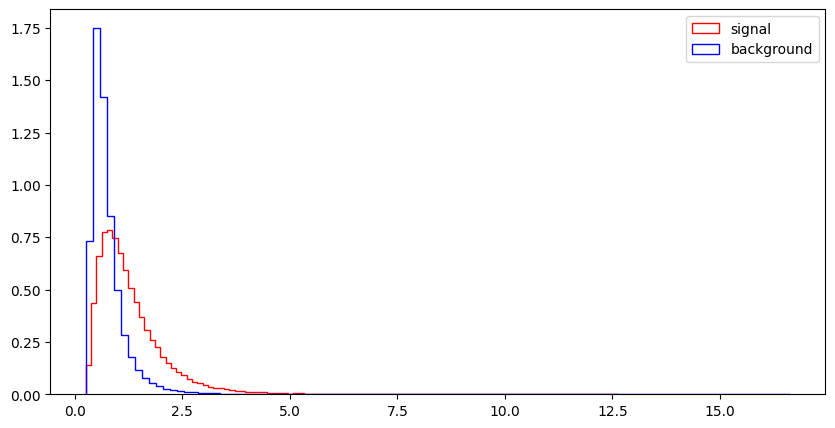

l_1_eta


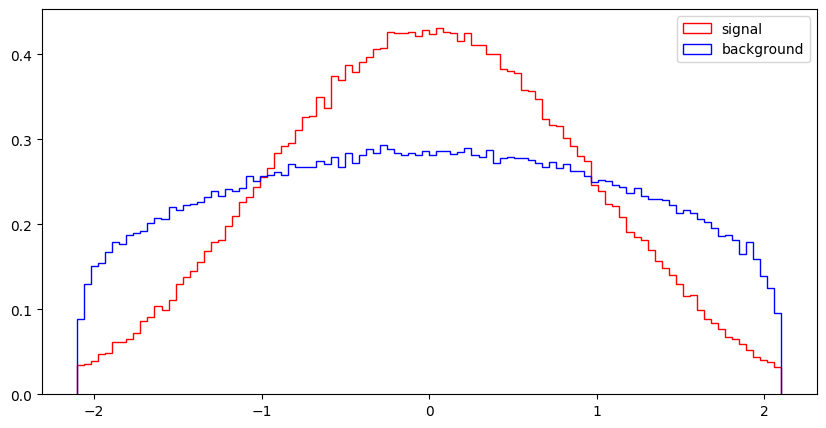

l_1_phi


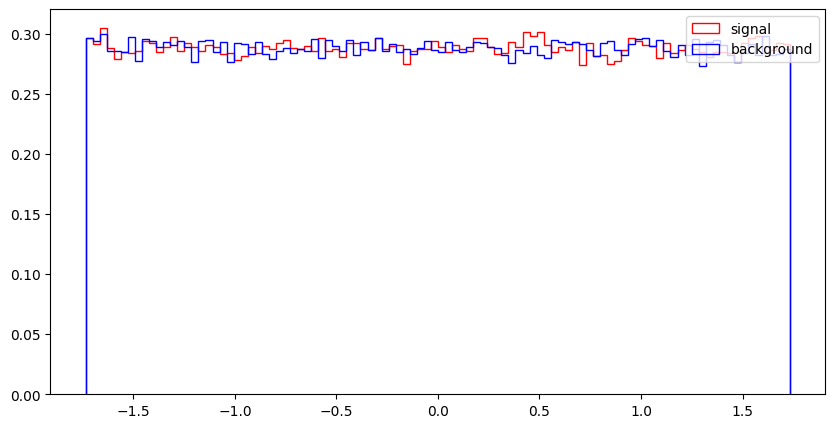

l_2_pT


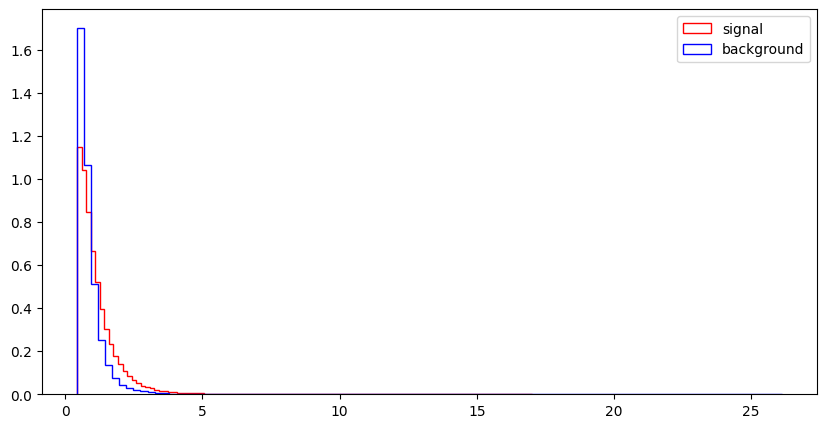

l_2_eta


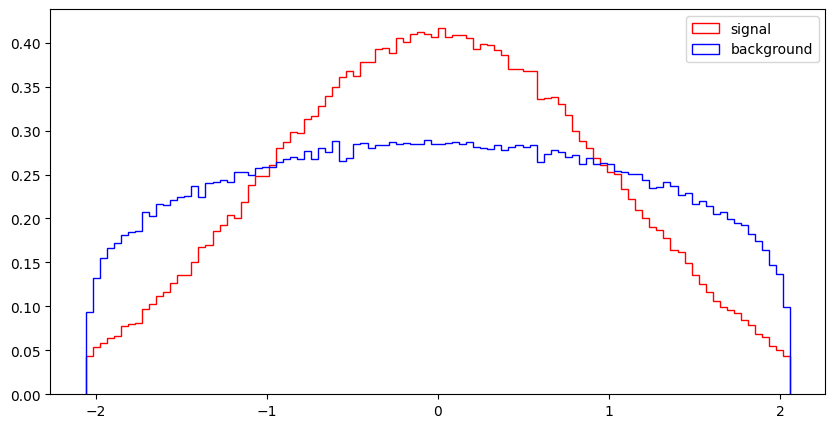

l_2_phi


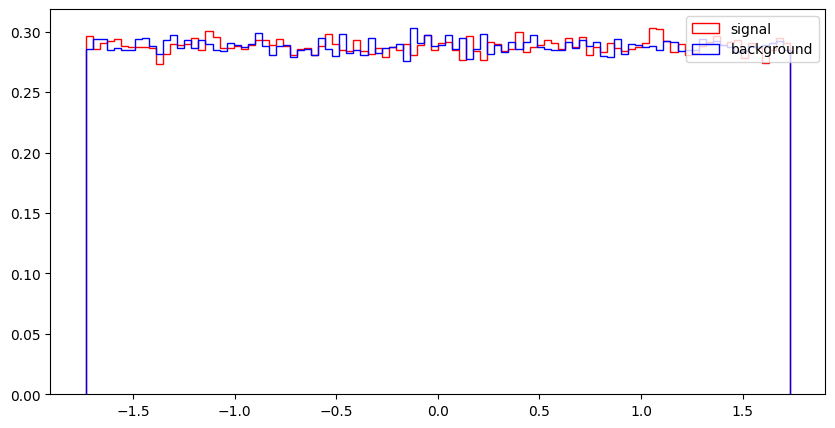

MET


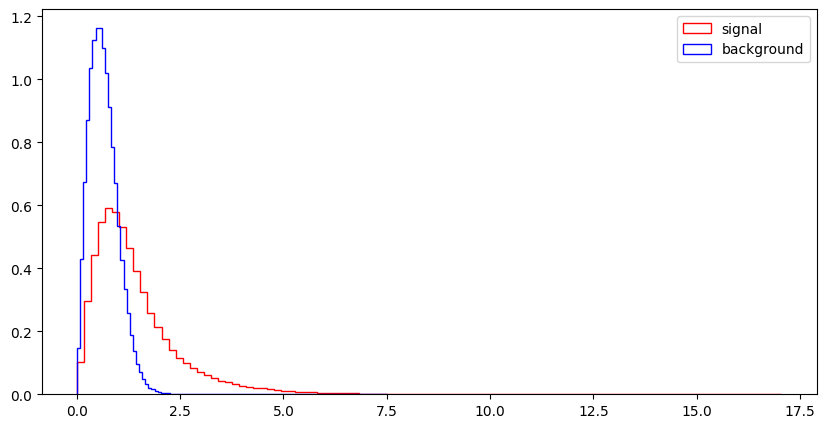

MET_phi


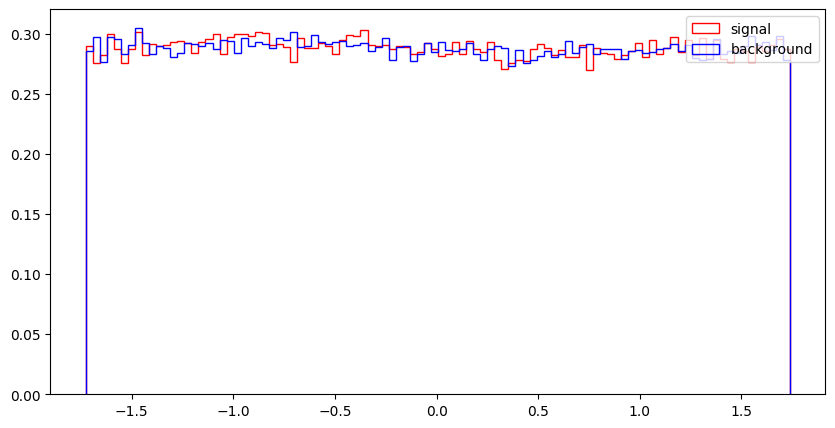

MET_rel


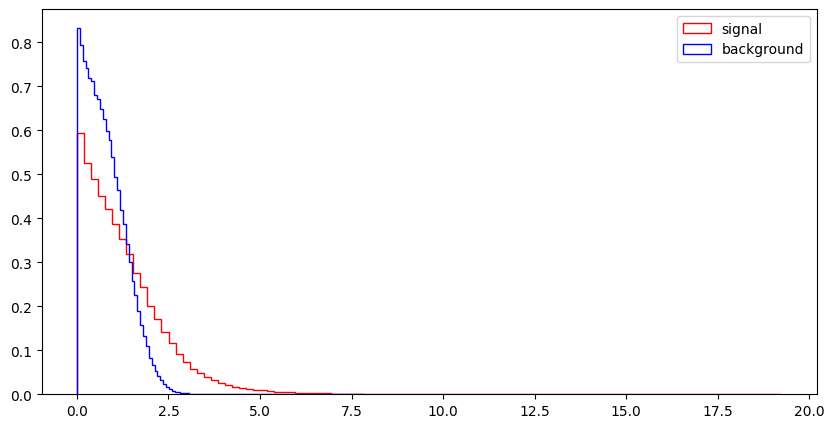

axial_MET


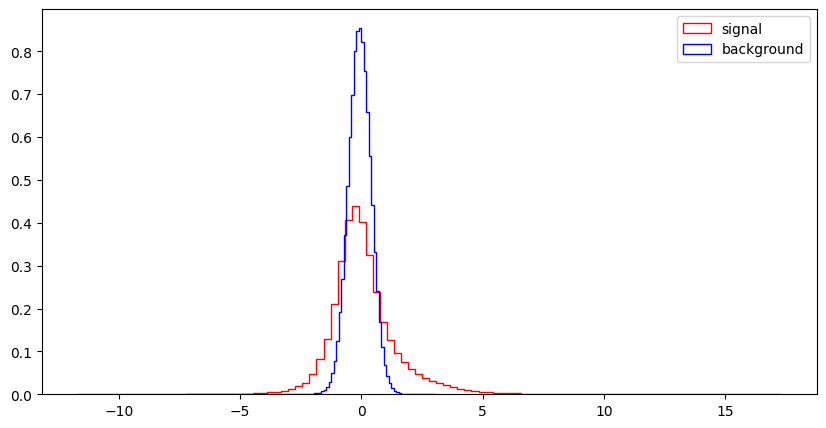

M_R


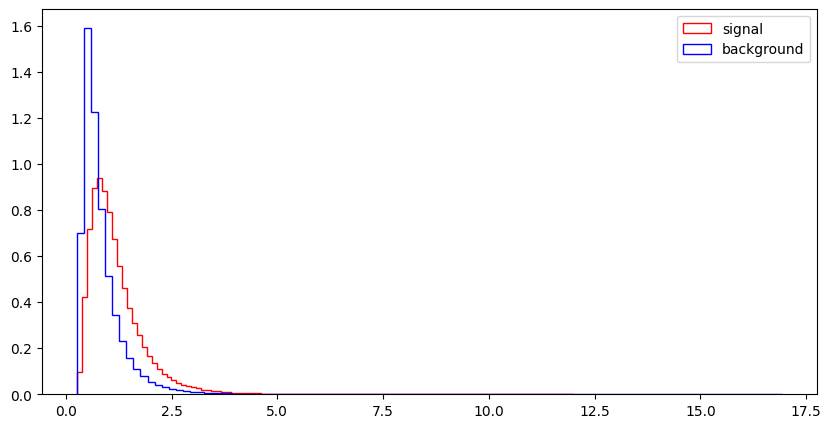

M_TR_2


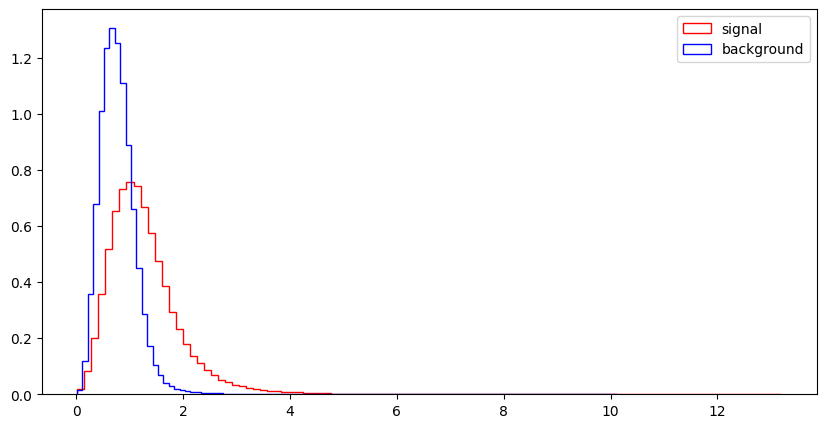

R


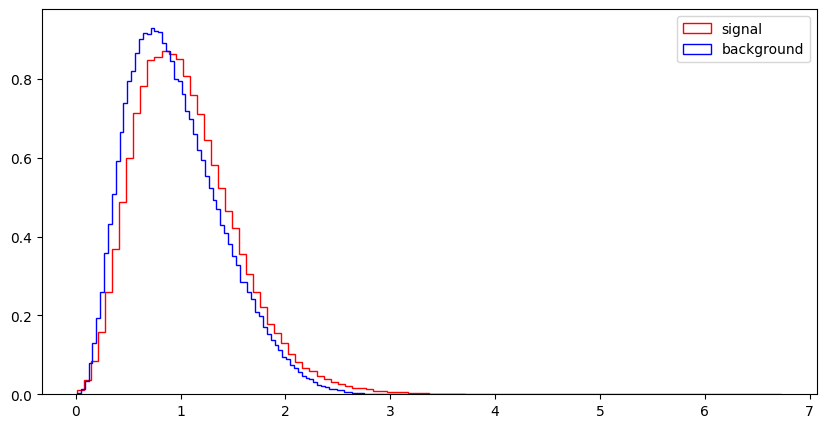

MT2


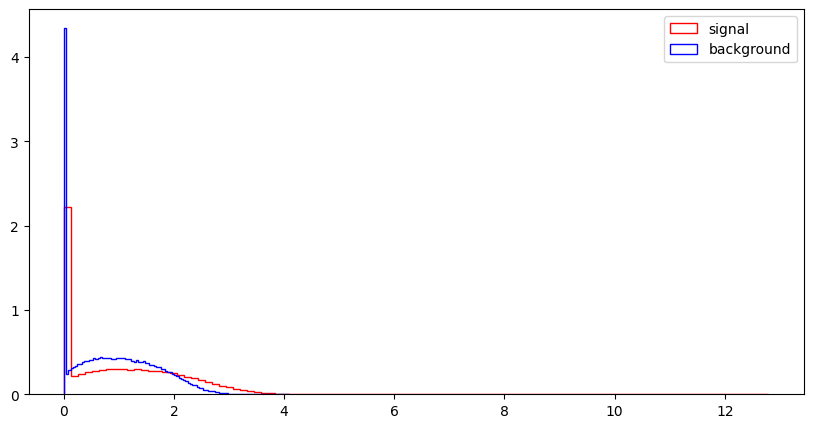

S_R


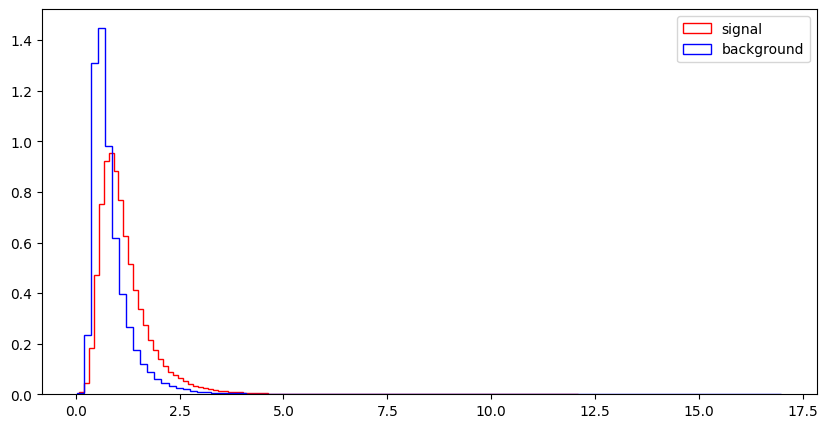

M_Delta_R


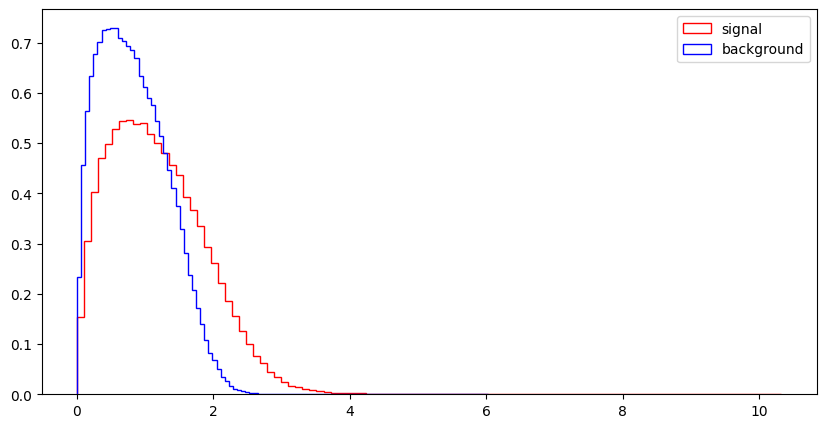

dPhi_r_b


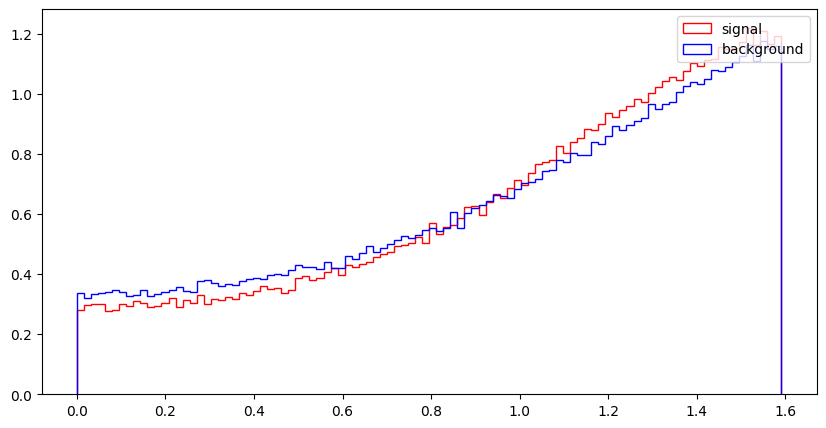

cos_theta_r1


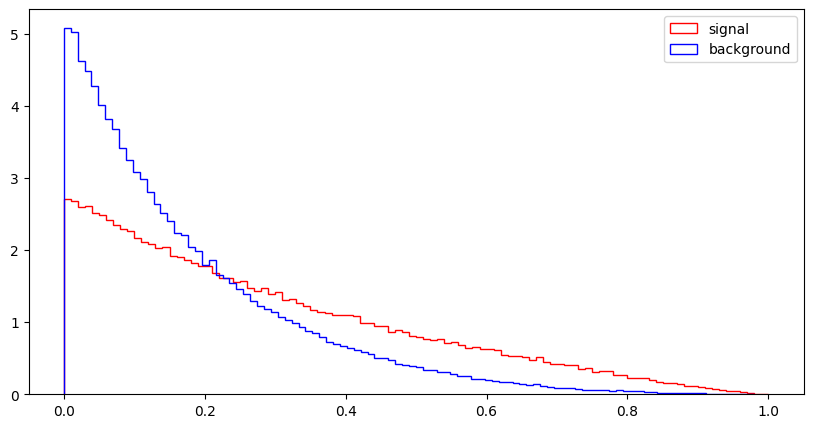

In [19]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

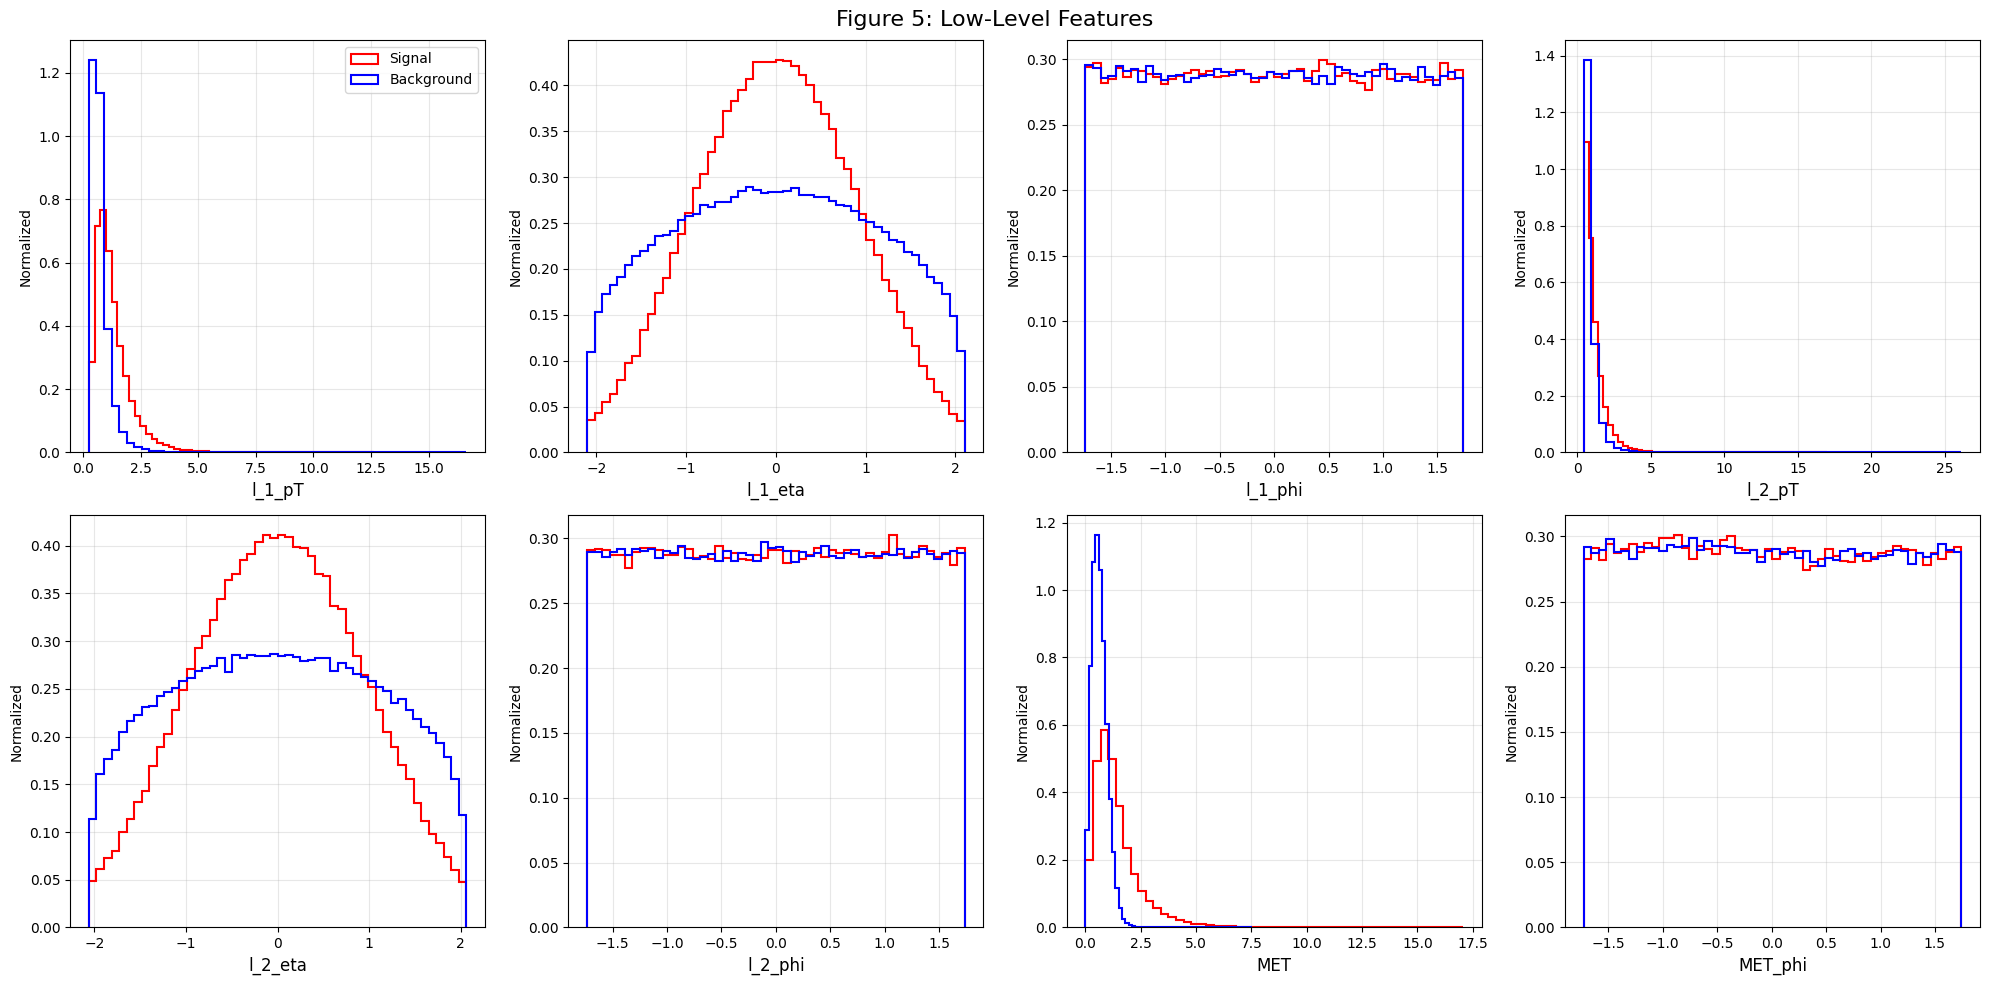

In [20]:
# Reproducing Figure 5 from the paper - low-level features

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(RawNames):
    ax = axes[i]
    ax.hist(np.array(df_sig[var]), bins=50, histtype="step", color="red", 
            label="Signal", density=True, linewidth=1.5)
    ax.hist(np.array(df_bkg[var]), bins=50, histtype="step", color="blue", 
            label="Background", density=True, linewidth=1.5)
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel("Normalized", fontsize=10)

    ax.grid(alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=10)

plt.suptitle("Figure 5: Low-Level Features", fontsize=16)
plt.tight_layout()
plt.show()

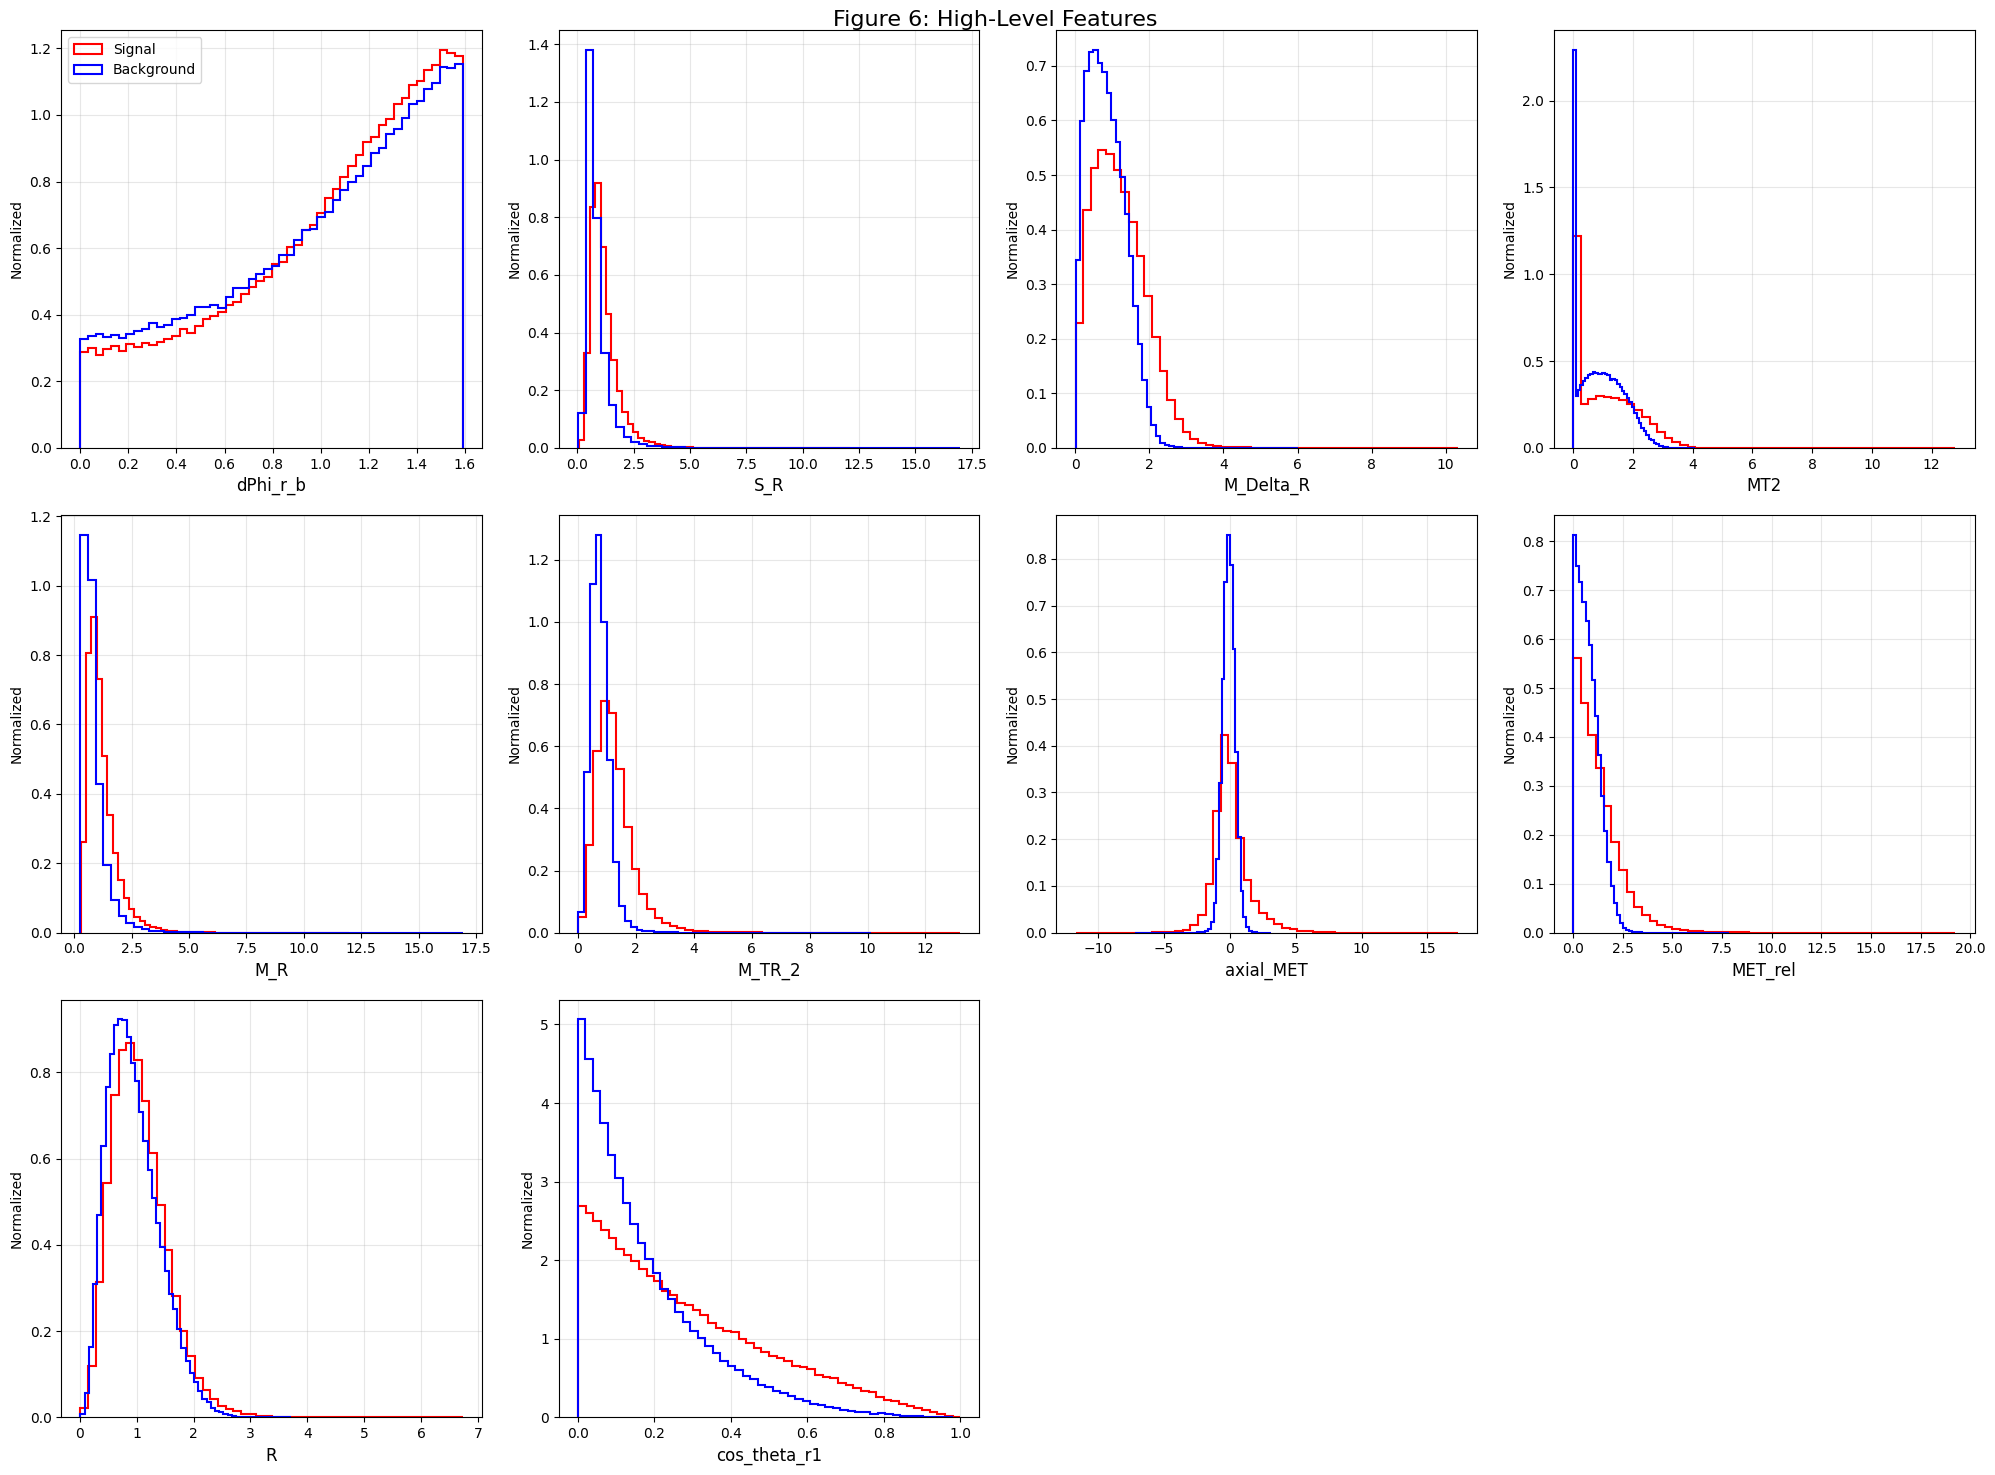

In [21]:
# Reproducing Figure 6 from the paper - high-level features

n_features = len(FeatureNames)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, var in enumerate(FeatureNames):
    ax = axes[i]
    ax.hist(np.array(df_sig[var]), bins=50, histtype="step", color="red", 
            label="Signal", density=True, linewidth=1.5)
    ax.hist(np.array(df_bkg[var]), bins=50, histtype="step", color="blue", 
            label="Background", density=True, linewidth=1.5)
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel("Normalized", fontsize=10)

    ax.grid(alpha=0.3)

    if i == 0:
        ax.legend(fontsize=10)

# Hiding unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Figure 6: High-Level Features", fontsize=16)
plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [70]:
# Exercise 4.1 (a)

def compare_distributions(df, column_name, selections, bins=50,
                          make_legend=True, **kwargs):
 
    # Looping through each group for comparison
    for label, selection in selections.items():
 
        # Setting consistent colors for clarity
        color = "red" if label == "signal" else "blue"
 
        # Plotting histogram for each selection
        plt.hist(df[selection][column_name], bins=bins, label=label, color=color, **kwargs)
 
    # Setting x-axis label
    plt.xlabel(column_name)
 
    # Showing legend only when needed
    if make_legend:
        plt.legend()
 
 
def compare_scatter(df, x_var_name, y_var_name, selections, make_legend=True):
 
    # Plotting the two variables for each selection
    for label, selection in selections.items():
        plt.scatter(df[selection][x_var_name],
                    df[selection][y_var_name],
                    label=label,
                    alpha=0.3)
 
    plt.xlabel(x_var_name)
    plt.ylabel(y_var_name)
 
    # Showing the legend only once
    if make_legend:
        plt.legend()
 
 
def make_pair_plot(df, columns, selections):
 
    n_columns = len(columns)
    plt.figure(figsize=(15, 15))
 
    plot_i = 0
 
    # Iterating over every x and y variable pair
    for i, x_var_name in enumerate(columns):
        for j, y_var_name in enumerate(columns):
            plot_i += 1
            plt.subplot(n_columns, n_columns, plot_i)
 
            # Ensuring the legend appears only one time
            make_legend = (plot_i == 1)
 
            # Plotting a histogram on the diagonal where x and y are the same
            if i == j:
                compare_distributions(df, x_var_name, selections,
                                      bins=50, make_legend=make_legend,
                                      histtype="step", density=1)
            else:
                # Plotting a scatter plot for off-diagonal elements
                compare_scatter(df, x_var_name, y_var_name, selections, make_legend=make_legend)
 
    plt.tight_layout()
    plt.show()

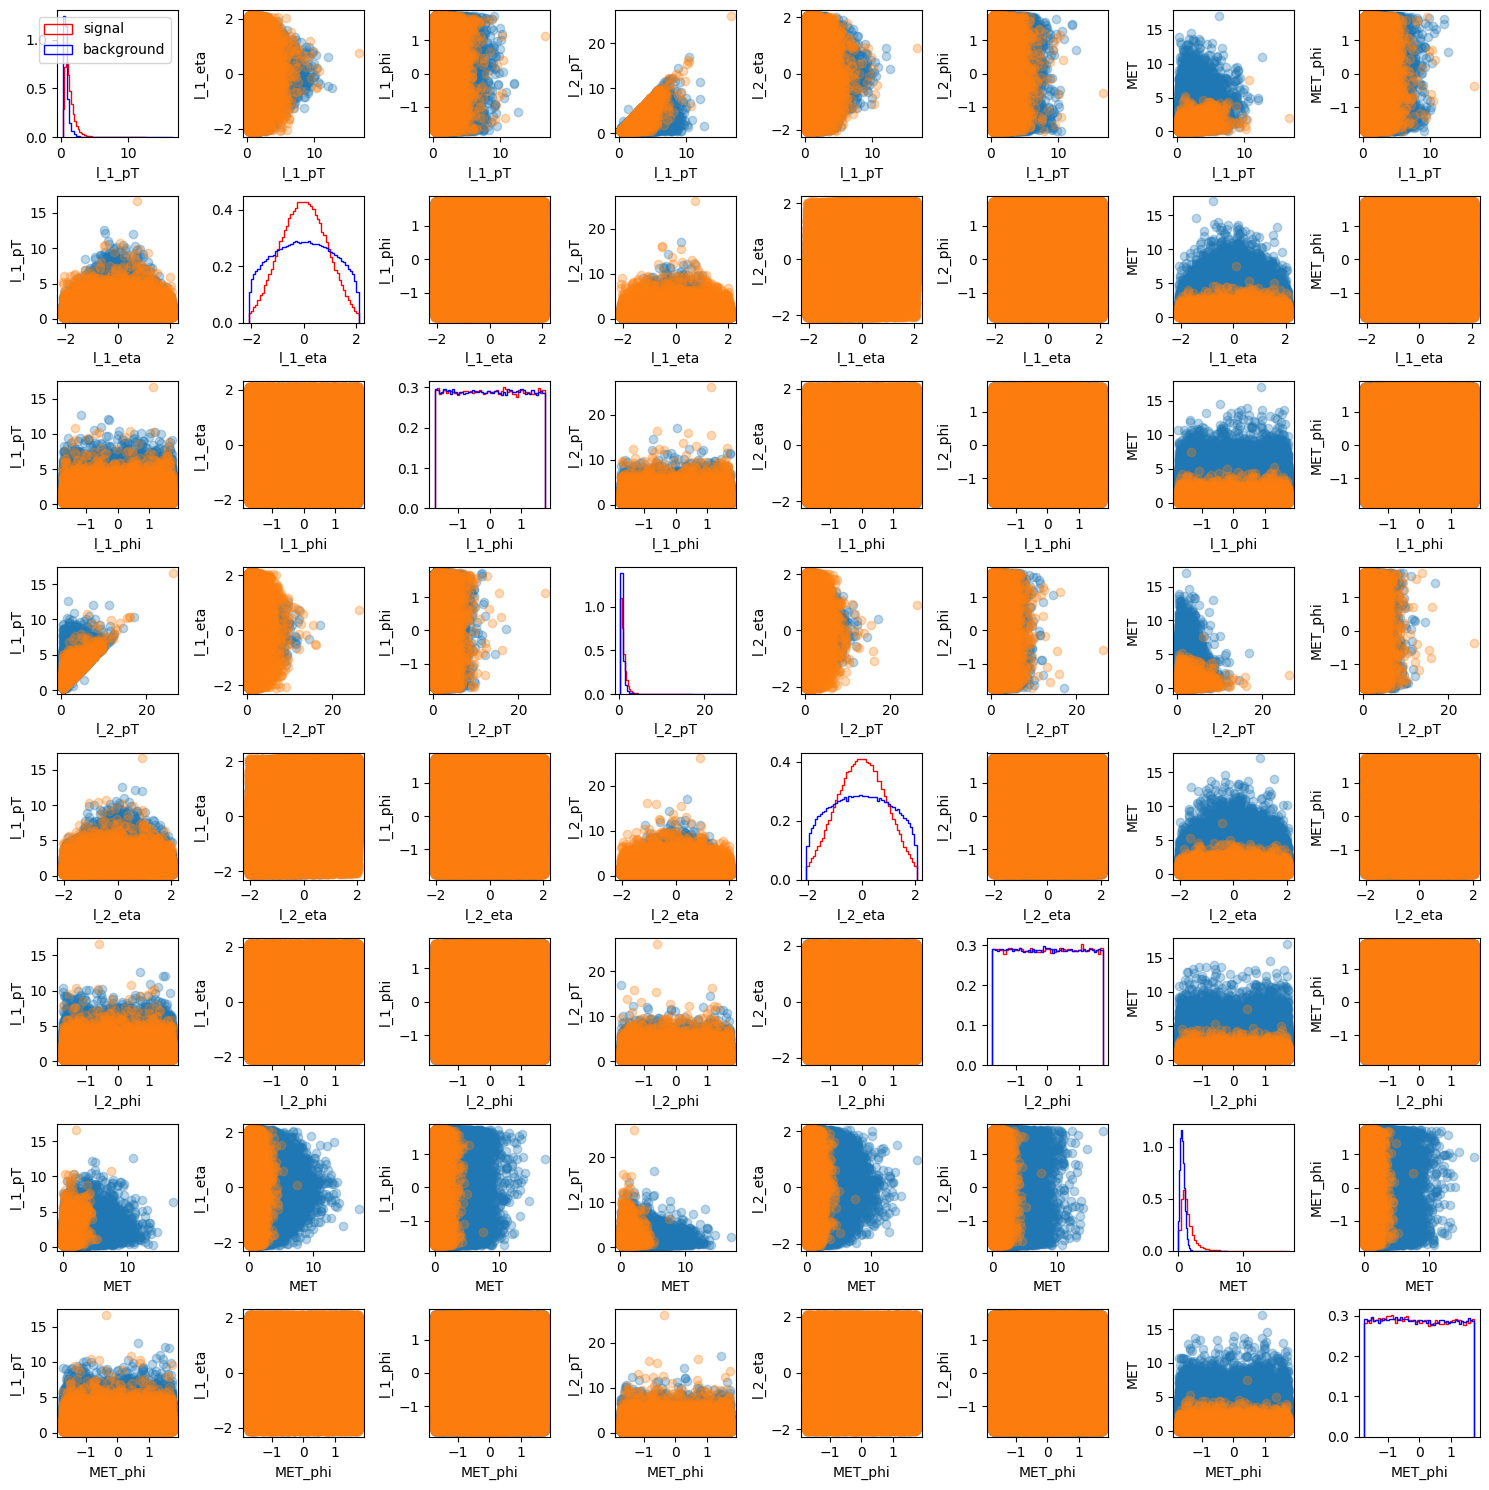

In [71]:
# Comparing signal and background for the raw variables
selection_dict = {"signal": df["signal"] == 1, "background": df["signal"] == 0}
make_pair_plot(df, RawNames, selection_dict)

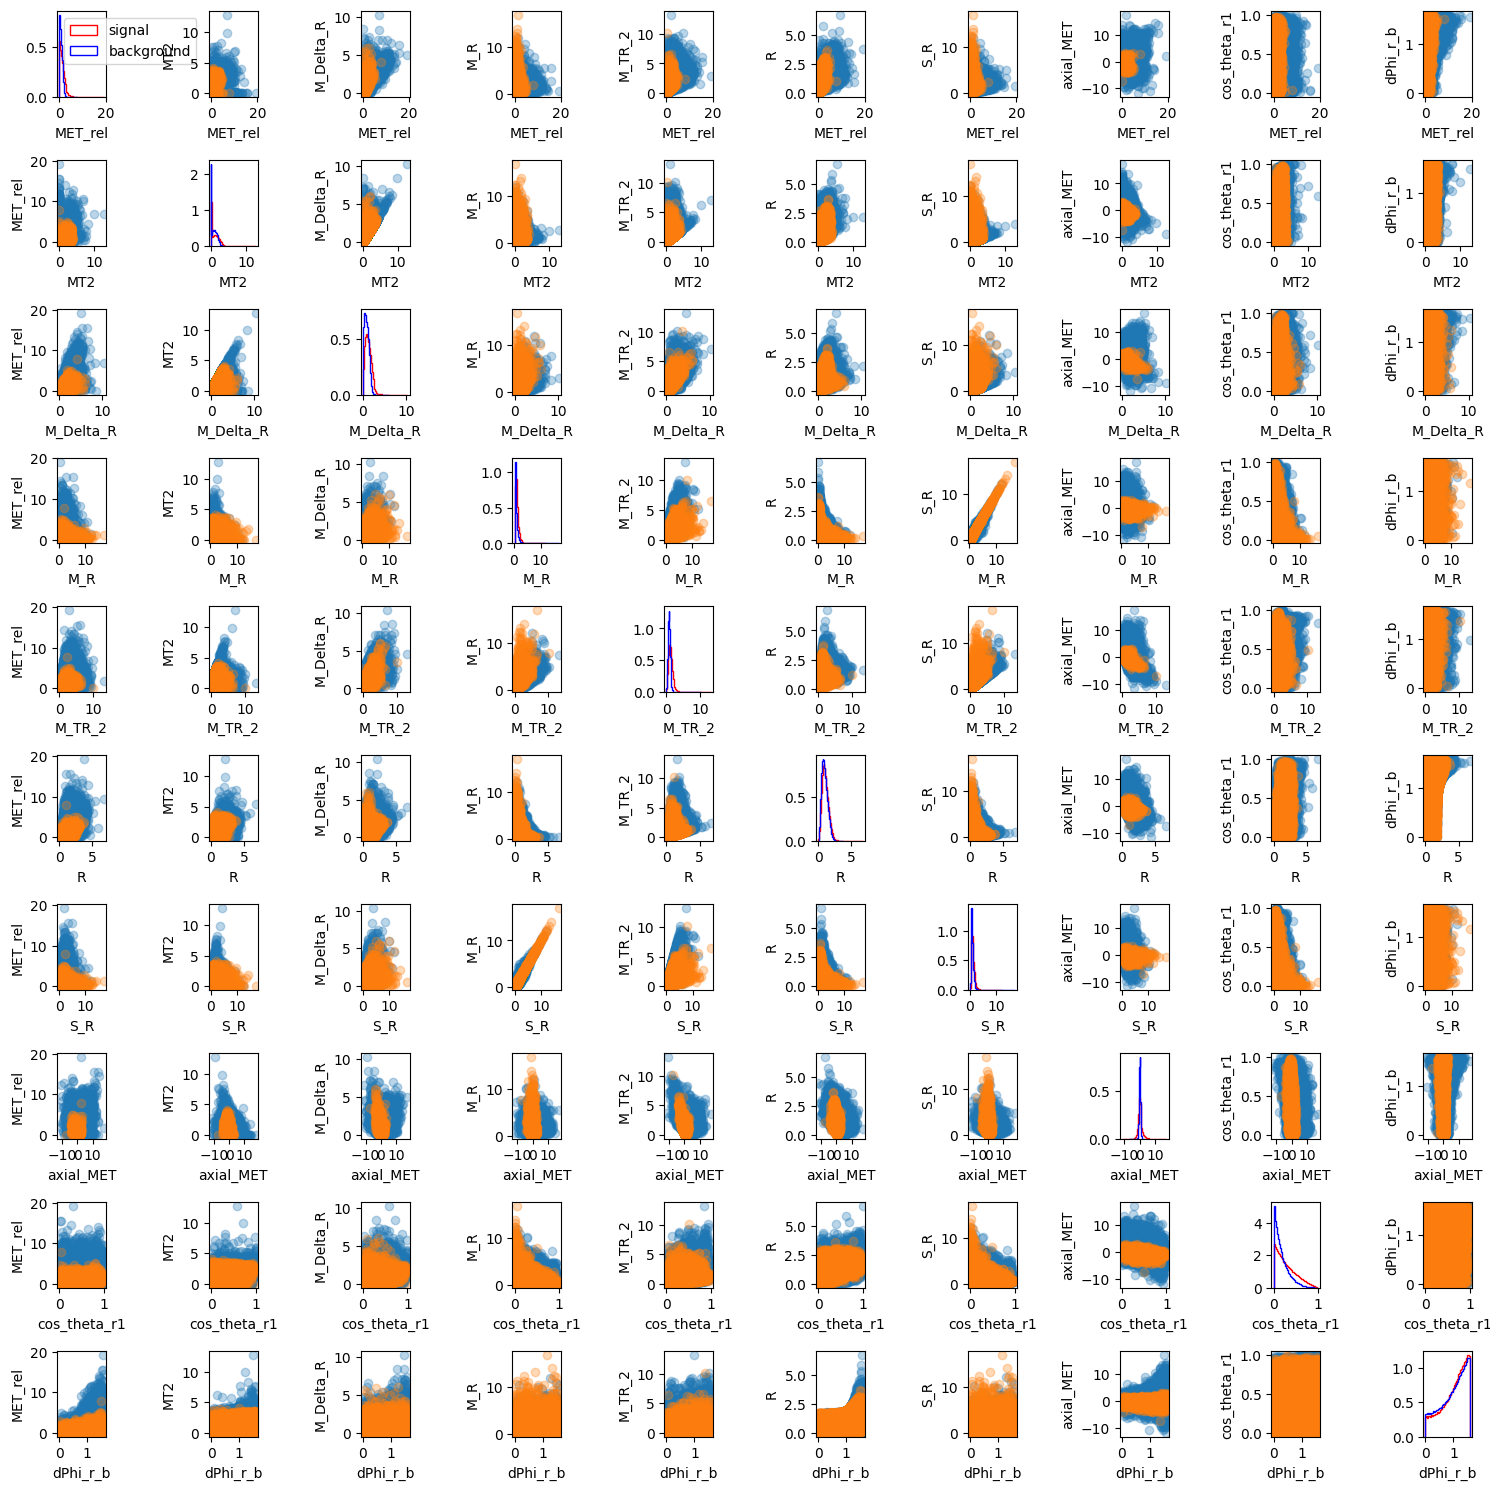

In [79]:
# Comparing signal and background for the high-level variables
make_pair_plot(df, sorted(FeatureNames), selection_dict)

In [76]:
# Exercise 4.1(b)

# Splitting the dataframe once at the start to improve performance
df_sig = df[df["signal"] == 1]
df_bkg = df[df["signal"] == 0]

def compare_distributions_fast(df_sig, df_bkg, column_name, bins=50, **kwargs):
    
    # Using pre-filtered dataframes to avoid re-evaluating the mask
    plt.hist(df_sig[column_name], bins=bins, label="signal", **kwargs)
    plt.hist(df_bkg[column_name], bins=bins, label="background", **kwargs)
    
    plt.xlabel(column_name)
    plt.legend()


def compare_scatter_fast(df_sig, df_bkg, x_var_name, y_var_name, make_legend=True):
    
    # Using the pre-separated dataframes directly
    plt.scatter(df_sig[x_var_name], df_sig[y_var_name], label="signal", alpha=0.3)
    plt.scatter(df_bkg[x_var_name], df_bkg[y_var_name], label="background", alpha=0.3)
    
    plt.xlabel(x_var_name)
    plt.ylabel(y_var_name)
    
    if make_legend:
        plt.legend()


def make_pair_plot_fast(df_sig, df_bkg, columns):
    
    n_columns = len(columns)
    plt.figure(figsize=(15, 15))
    
    plot_i = 0
    
    # Iterating over every x and y variable pair
    for i, x_var_name in enumerate(columns):
        for j, y_var_name in enumerate(columns):
            plot_i += 1
            plt.subplot(n_columns, n_columns, plot_i)
            
            make_legend = (plot_i == 1)
            
            if i == j:
                compare_distributions_fast(df_sig, df_bkg, x_var_name,
                                           bins=50, histtype="step", density=1)
            else:
                compare_scatter_fast(df_sig, df_bkg, x_var_name, y_var_name,
                                     make_legend=make_legend)
    
    plt.tight_layout()
    plt.show()

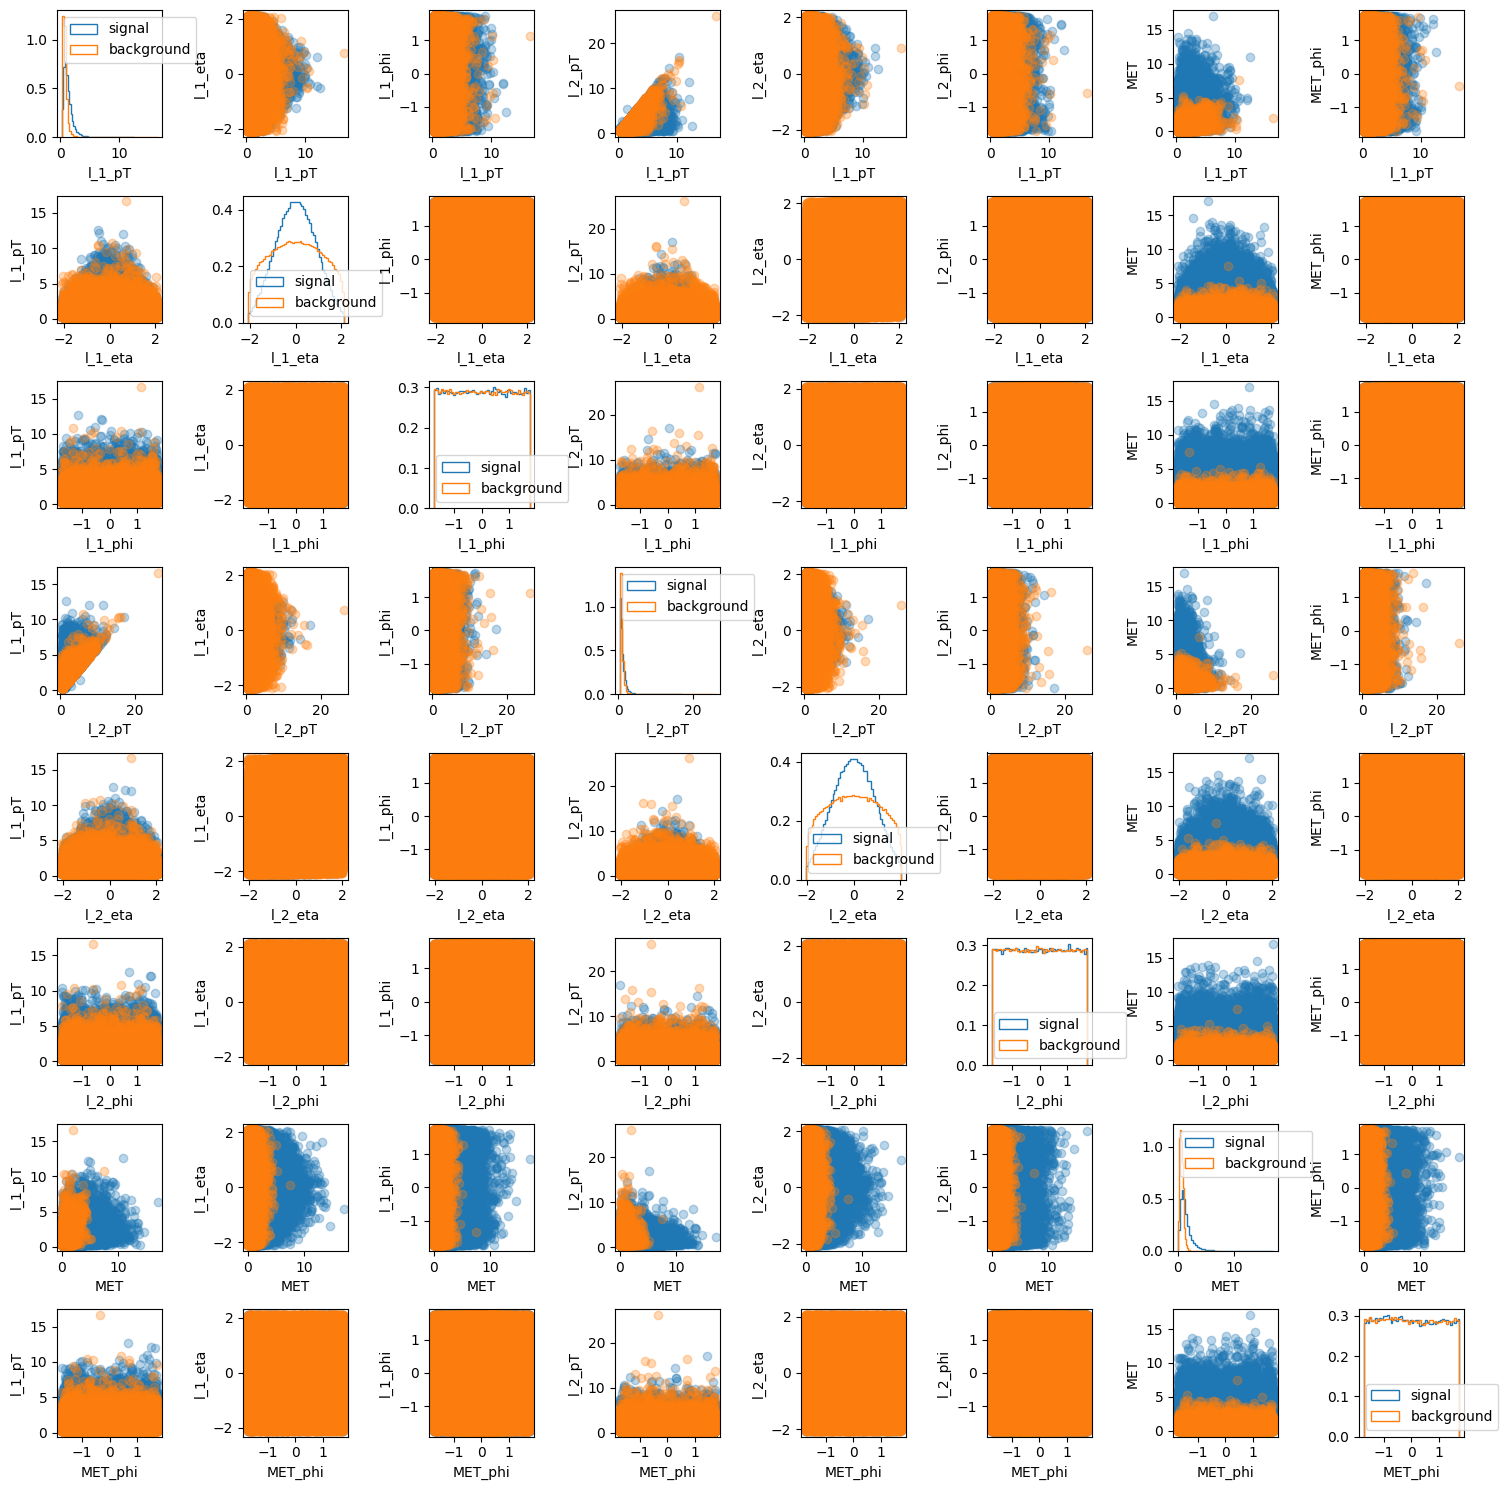

In [77]:
make_pair_plot_fast(df_sig, df_bkg, RawNames)

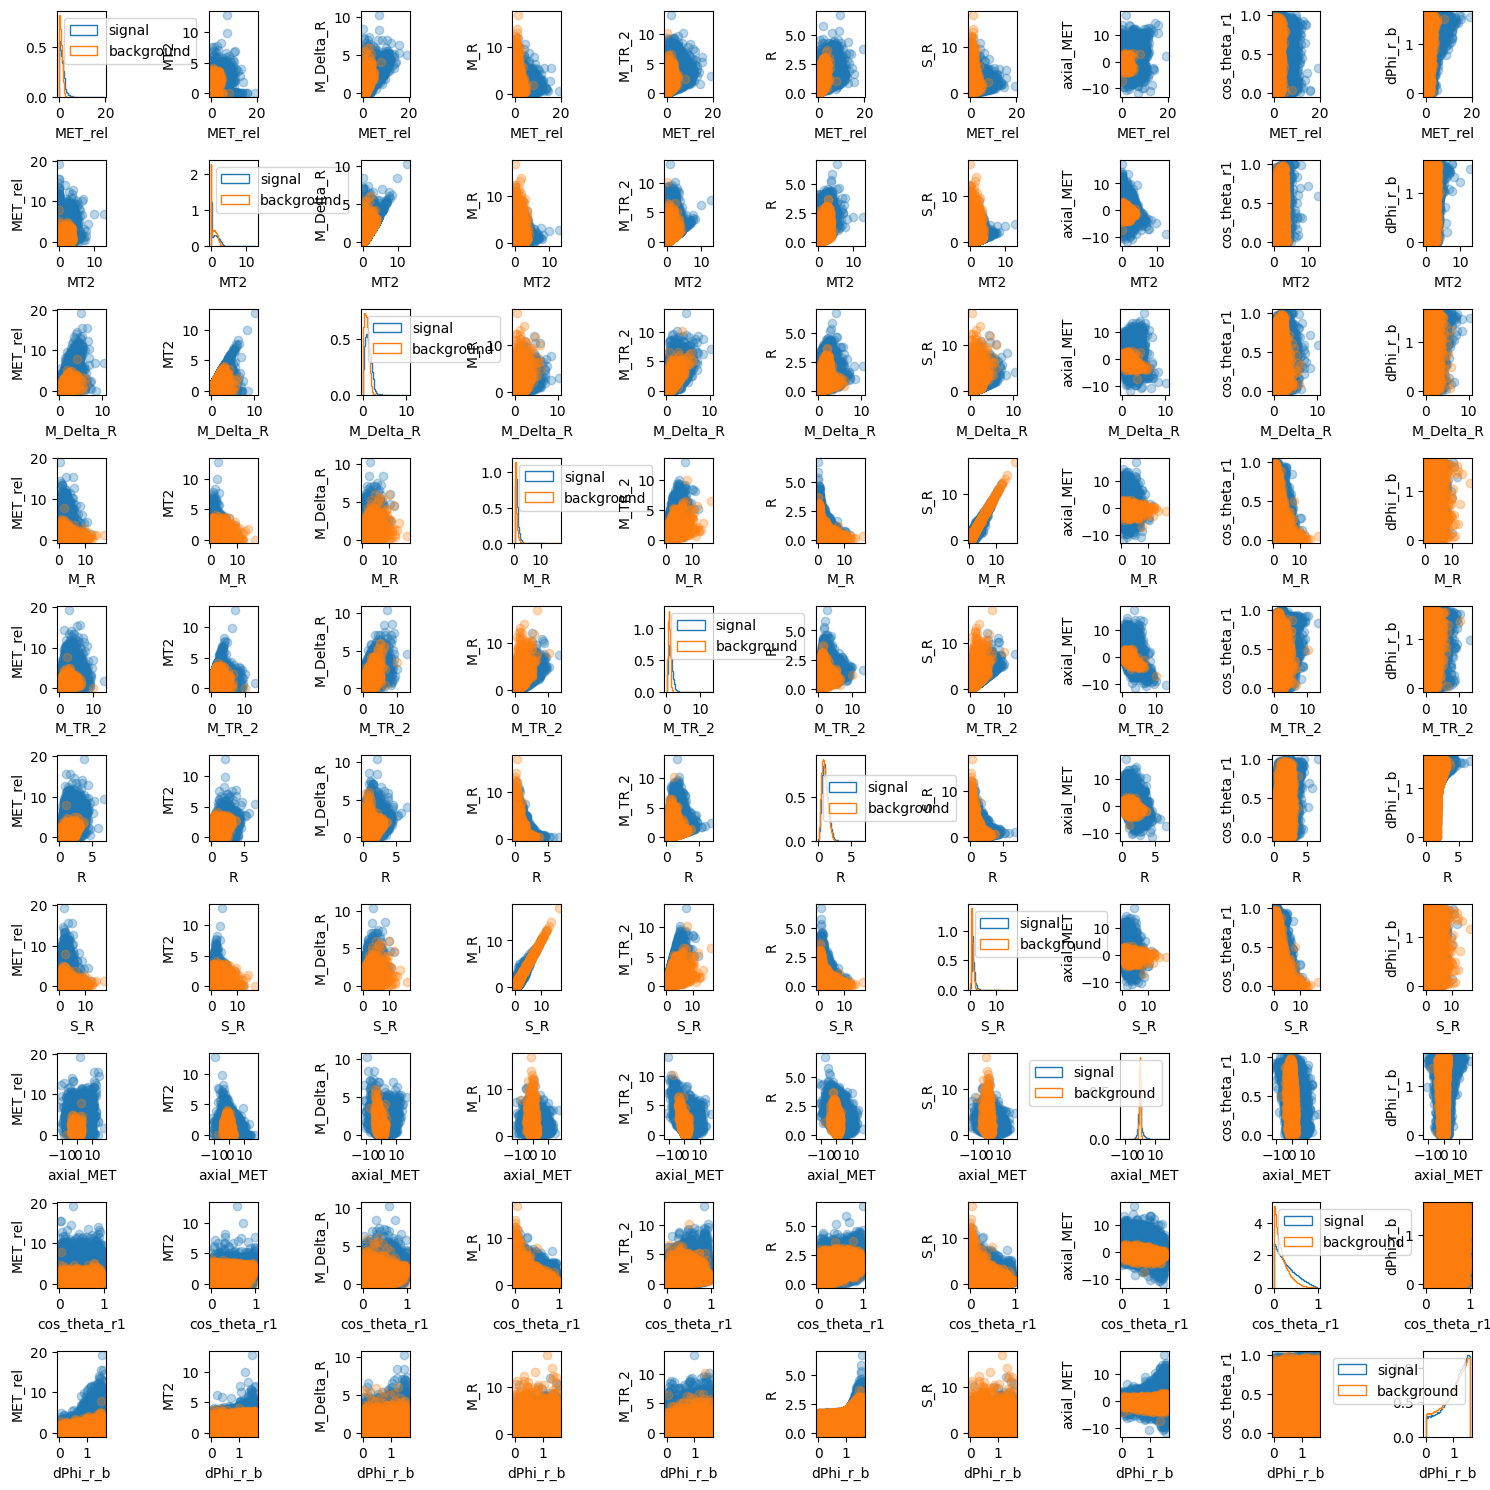

In [78]:
make_pair_plot_fast(df_sig, df_bkg, sorted(FeatureNames))

A simple way to speed up the pair plot is to separate the data into signal and background one time before making the plots. In part a, each subplot was repeatedly using dataframe selections inside the loop. That means the same filtering work was being done again and again. In part b, I first made df_sig and df_bkg and then used them directly in the histogram and scatter functions. This reduces repeated dataframe indexing and makes the plotting faster.

Another way to make histograms faster would be to use numpy.histogram first and then plot the result, instead of calling plt.hist every time. That would avoid recalculating the histogram bins inside each subplot.

c)
The high-level features seem better for separating signal from background than the low-level features.

For the low-level variables, MET and maybe l_1_pT looked more useful than the others. Variables like eta and phi did not seem to separate the two groups very clearly.

For the high-level variables, M_R, M_TR_2, MT2, R, and MET_rel looked the most helpful. Their signal and background distributions looked more different, so they seem better for classification.

So in general, the high-level observables seem to do a better job than the raw observables.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [34]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [35]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [37]:
# Exercise 4.2(b)
# use numpy to compute covariance and correlation matrices
# first do it for all observables
# then separately for low-level and high-level features

import numpy as np

all_vars = VarNames[1:]
low_vars = RawNames
high_vars = sorted(FeatureNames)

# Extracting numpy arrays for each group of variables
X_all = df[all_vars].to_numpy()
cov_all = np.cov(X_all, rowvar=False)
corr_all = np.corrcoef(X_all, rowvar=False)
 
# Repeating for low-level features only
X_low = df[low_vars].to_numpy()
cov_low = np.cov(X_low, rowvar=False)
corr_low = np.corrcoef(X_low, rowvar=False)
 
# Repeating for high-level features only
X_high = df[high_vars].to_numpy()
cov_high = np.cov(X_high, rowvar=False)
corr_high = np.corrcoef(X_high, rowvar=False)

In [38]:
# Exercise 4.2(c)
# use tabulate to print the matrices in a cleaner table

from IPython.display import HTML, display
import tabulate
 
def format_matrix_table(matrix, columns, decimals=3):
    """Building a list-of-lists table from a matrix, with row labels."""
    table = []
    for i in range(len(columns)):
        # Rounding each entry to specified decimal places
        row = [columns[i]] + [round(matrix[i, j], decimals) for j in range(len(columns))]
        table.append(row)
    return table

In [41]:
# Embedding covariance matrix for all observables
print("Covariance Matrix - All Observables")
table = format_matrix_table(cov_all, all_vars, decimals=3)
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=[""] + all_vars)))
 
# Embedding correlation matrix for all observables
print("\nCorrelation Matrix - All Observables")
table = format_matrix_table(corr_all, all_vars, decimals=3)
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=[""] + all_vars)))
 
# Embedding covariance matrix for low-level features
print("\nCovariance Matrix - Low-Level Features")
table = format_matrix_table(cov_low, low_vars, decimals=3)
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=[""] + low_vars)))
 
# Embedding correlation matrix for low-level features
print("\nCorrelation Matrix - Low-Level Features")
table = format_matrix_table(corr_low, low_vars, decimals=3)
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=[""] + low_vars)))
 
# Embedding covariance matrix for high-level features
print("\nCovariance Matrix - High-Level Features")
table = format_matrix_table(cov_high, high_vars, decimals=3)
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=[""] + high_vars)))
 
# Embedding correlation matrix for high-level features
print("\nCorrelation Matrix - High-Level Features")
table = format_matrix_table(corr_high, high_vars, decimals=3)
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=[""] + high_vars)))

Covariance Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054



Correlation Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272



Covariance Matrix - Low-Level Features


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



Covariance Matrix - High-Level Features


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,0.79,0.409,0.415,0.044,0.302,0.249,0.082,-0.12,0.055,0.146
MT2,0.409,0.738,0.433,-0.037,0.189,0.232,-0.011,-0.461,0.045,0.021
M_Delta_R,0.415,0.433,0.389,0.074,0.242,0.165,0.096,-0.233,0.039,0.042
M_R,0.044,-0.037,0.074,0.392,0.21,-0.113,0.38,0.017,-0.014,-0.029
M_TR_2,0.302,0.189,0.242,0.21,0.338,0.104,0.228,-0.185,0.052,0.058
R,0.249,0.232,0.165,-0.113,0.104,0.222,-0.083,-0.181,0.058,0.087
S_R,0.082,-0.011,0.096,0.38,0.228,-0.083,0.382,-0.041,-0.01,-0.003
axial_MET,-0.12,-0.461,-0.233,0.017,-0.185,-0.181,-0.041,1.005,-0.054,-0.025
cos_theta_r1,0.055,0.045,0.039,-0.014,0.052,0.058,-0.01,-0.054,0.039,0.009
dPhi_r_b,0.146,0.021,0.042,-0.029,0.058,0.087,-0.003,-0.025,0.009,0.19



Correlation Matrix - High-Level Features


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,1,0.535,0.748,0.078,0.584,0.595,0.15,-0.134,0.316,0.378
MT2,0.535,1,0.809,-0.068,0.379,0.574,-0.021,-0.535,0.264,0.056
M_Delta_R,0.748,0.809,1,0.189,0.668,0.564,0.249,-0.373,0.319,0.155
M_R,0.078,-0.068,0.189,1,0.577,-0.383,0.981,0.027,-0.116,-0.106
M_TR_2,0.584,0.379,0.668,0.577,1,0.38,0.635,-0.317,0.451,0.229
R,0.595,0.574,0.564,-0.383,0.38,1,-0.287,-0.383,0.627,0.424
S_R,0.15,-0.021,0.249,0.981,0.635,-0.287,1,-0.067,-0.085,-0.013
axial_MET,-0.134,-0.535,-0.373,0.027,-0.317,-0.383,-0.067,1,-0.272,-0.057
cos_theta_r1,0.316,0.264,0.319,-0.116,0.451,0.627,-0.085,-0.272,1,0.106
dPhi_r_b,0.378,0.056,0.155,-0.106,0.229,0.424,-0.013,-0.057,0.106,1


In [42]:
# Wrapping parts b and c into a single reusable function
# Takes a dataframe, list of column names, and optional decimals
 
def show_cov_corr_tables(df, columns, decimals=3):
    """Computing covariance and correlation matrices for the given columns
    and embedding them as HTML tables in the notebook."""
 
    # Extracting selected columns as a numpy array
    X = df[columns].to_numpy()
 
    # Computing covariance and correlation matrices
    cov_mat = np.cov(X, rowvar=False)
    corr_mat = np.corrcoef(X, rowvar=False)
 
    # Building and displaying the covariance table
    print("Covariance Matrix")
    cov_table = format_matrix_table(cov_mat, columns, decimals=decimals)
    display(HTML(tabulate.tabulate(cov_table, tablefmt='html', headers=[""] + columns)))
 
    # Building and displaying the correlation table
    print("\nCorrelation Matrix")
    corr_table = format_matrix_table(corr_mat, columns, decimals=decimals)
    display(HTML(tabulate.tabulate(corr_table, tablefmt='html', headers=[""] + columns)))
 
    return cov_mat, corr_mat

In [43]:
# Testing the function on each group
print("=== All Observables ===")
cov_all, corr_all = show_cov_corr_tables(df, all_vars, decimals=3)
 
print("\n=== Low-Level Features ===")
cov_low, corr_low = show_cov_corr_tables(df, low_vars, decimals=3)
 
print("\n=== High-Level Features ===")
cov_high, corr_high = show_cov_corr_tables(df, high_vars, decimals=3)


=== All Observables ===
Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001,0.098,-0.01,0.364,0.287,-0.06,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0,0,-0.001,-0.001,-0.001,0
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0,0.001,0.001,0.001,0.001,0
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0,0.001,-0.001,-0.001,0,0,0.001,-0.001,0.001,-0,0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0,0
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003,-0.005,-0,-0.001,-0.001,-0,0,-0.002,-0.001,-0.002,0
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.79,-0.12,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.01,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0,-0.12,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054



Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001,0.16,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0,-0.001,-0.002,-0.002,0.002
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002,-0.001,0.078,0.797,0.43,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0,0.001,-0.001,-0.001,0,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003,0.704,0.176,0.264,0.72,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1,-0.005,-0,-0.002,-0.002,-0,0,-0.003,-0.001,-0.004,0.001
MET_rel,0.16,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1,-0.134,0.078,0.584,0.595,0.535,0.15,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0,-0.134,1,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272



=== Low-Level Features ===
Covariance Matrix


...

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



=== High-Level Features ===
Covariance Matrix


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,0.79,0.409,0.415,0.044,0.302,0.249,0.082,-0.12,0.055,0.146
MT2,0.409,0.738,0.433,-0.037,0.189,0.232,-0.011,-0.461,0.045,0.021
M_Delta_R,0.415,0.433,0.389,0.074,0.242,0.165,0.096,-0.233,0.039,0.042
M_R,0.044,-0.037,0.074,0.392,0.21,-0.113,0.38,0.017,-0.014,-0.029
M_TR_2,0.302,0.189,0.242,0.21,0.338,0.104,0.228,-0.185,0.052,0.058
R,0.249,0.232,0.165,-0.113,0.104,0.222,-0.083,-0.181,0.058,0.087
S_R,0.082,-0.011,0.096,0.38,0.228,-0.083,0.382,-0.041,-0.01,-0.003
axial_MET,-0.12,-0.461,-0.233,0.017,-0.185,-0.181,-0.041,1.005,-0.054,-0.025
cos_theta_r1,0.055,0.045,0.039,-0.014,0.052,0.058,-0.01,-0.054,0.039,0.009
dPhi_r_b,0.146,0.021,0.042,-0.029,0.058,0.087,-0.003,-0.025,0.009,0.19



Correlation Matrix


,MET_rel,MT2,M_Delta_R,M_R,M_TR_2,R,S_R,axial_MET,cos_theta_r1,dPhi_r_b
MET_rel,1,0.535,0.748,0.078,0.584,0.595,0.15,-0.134,0.316,0.378
MT2,0.535,1,0.809,-0.068,0.379,0.574,-0.021,-0.535,0.264,0.056
M_Delta_R,0.748,0.809,1,0.189,0.668,0.564,0.249,-0.373,0.319,0.155
M_R,0.078,-0.068,0.189,1,0.577,-0.383,0.981,0.027,-0.116,-0.106
M_TR_2,0.584,0.379,0.668,0.577,1,0.38,0.635,-0.317,0.451,0.229
R,0.595,0.574,0.564,-0.383,0.38,1,-0.287,-0.383,0.627,0.424
S_R,0.15,-0.021,0.249,0.981,0.635,-0.287,1,-0.067,-0.085,-0.013
axial_MET,-0.134,-0.535,-0.373,0.027,-0.317,-0.383,-0.067,1,-0.272,-0.057
cos_theta_r1,0.316,0.264,0.319,-0.116,0.451,0.627,-0.085,-0.272,1,0.106
dPhi_r_b,0.378,0.056,0.155,-0.106,0.229,0.424,-0.013,-0.057,0.106,1


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

In [44]:
# Exercise 5.1(a)
# Checking which cut style works best for each observable

signal = df[df["signal"] == 1]
background = df[df["signal"] == 0]
all_observables = VarNames[1:]

# Using the signal mean as mu for the absolute-value cut styles
mu_dict = dict()
for var in all_observables:
    mu_dict[var] = signal[var].mean()


def pass_selection(x, x_c, strategy, mu=None):
    
    # Applying strategy 1: x > x_c
    if strategy == 1:
        return x > x_c
    
    # Applying strategy 2: x < x_c
    elif strategy == 2:
        return x < x_c
    
    # Applying strategy 3: |x - mu| > x_c
    elif strategy == 3:
        return np.abs(x - mu) > x_c
    
    # Applying strategy 4: |x - mu| < x_c
    elif strategy == 4:
        return np.abs(x - mu) < x_c
    
    # Handling invalid strategy values
    else:
        return np.zeros(len(x), dtype=bool)


# Making a helper for computing efficiency after a cut
def efficiency(x, x_c, strategy, mu=None):
    
    # Counting events that pass the selection
    passed = pass_selection(x, x_c, strategy, mu=mu)
    
    # Returning fraction of events that pass
    return np.sum(passed) / float(len(x))


# Making a helper for scanning cut values
def get_scan_values(x, strategy, n_points=100, mu=None):
    
    # Scanning directly over x for one-sided cuts
    if strategy == 1 or strategy == 2:
        return np.linspace(np.min(x), np.max(x), n_points)
    
    # Scanning over distance from mu for absolute-value cuts
    elif strategy == 3 or strategy == 4:
        d = np.abs(x - mu)
        return np.linspace(np.min(d), np.max(d), n_points)
    
    # Returning an empty array for safety if strategy is invalid
    else:
        return np.array([])


# Storing the best cut style for each observable
best_strategy_dict = dict()

for var in all_observables:
    
    # Extracting signal and background values
    x_sig = np.array(signal[var])
    x_bkg = np.array(background[var])
    x_all = np.array(df[var])
    mu = mu_dict[var]
    
    # Initializing best score tracking
    best_score = -np.inf
    best_strategy = None
    
    # Checking all four strategies
    for strategy in [1, 2, 3, 4]:
        
        # Building scan values for the current strategy
        x_scan = get_scan_values(x_all, strategy, n_points=100, mu=mu)
        
        # Tracking the best score for this strategy
        strategy_best_score = -np.inf
        
        for x_c in x_scan:
            
            # Computing signal and background efficiencies
            eps_s = efficiency(x_sig, x_c, strategy, mu=mu)
            eps_b = efficiency(x_bkg, x_c, strategy, mu=mu)
            
            # Measuring separation between signal and background
            score = eps_s - eps_b
            
            if score > strategy_best_score:
                strategy_best_score = score
        
        # Updating the overall best strategy for this variable
        if strategy_best_score > best_score:
            best_score = strategy_best_score
            best_strategy = strategy
    
    best_strategy_dict[var] = best_strategy


# Printing the preferred cut style for each observable
for var in all_observables:
    print(var, "-> strategy", best_strategy_dict[var])

l_1_pT -> strategy 1
l_1_eta -> strategy 4
l_1_phi -> strategy 4
l_2_pT -> strategy 1
l_2_eta -> strategy 4
l_2_phi -> strategy 3
MET -> strategy 1
MET_phi -> strategy 4
MET_rel -> strategy 1
axial_MET -> strategy 3
M_R -> strategy 1
M_TR_2 -> strategy 1
R -> strategy 1
MT2 -> strategy 3
S_R -> strategy 1
M_Delta_R -> strategy 1
dPhi_r_b -> strategy 1
cos_theta_r1 -> strategy 1


### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

In [45]:
# Exercise 5.2
# Plotting TPR and FPR as functions of the cut value x_c
# Using the best strategy chosen in part a for each observable


def get_tpr_fpr_curves(df, var, strategy, n_points=100):
    
    # Separating signal and background values for the selected observable
    x_sig = np.array(df[df["signal"] == 1][var])
    x_bkg = np.array(df[df["signal"] == 0][var])
    x_all = np.array(df[var])
    
    # Using the signal mean as mu for absolute-value cut styles
    mu = x_sig.mean()
    
    # Building scan values for the chosen cut strategy
    x_scan = get_scan_values(x_all, strategy, n_points=n_points, mu=mu)
    
    # Storing efficiency values across the scan
    tpr_list = []
    fpr_list = []
    
    # Iterating over each cut value
    for x_c in x_scan:
        
        # Computing true positive rate for signal
        tpr = efficiency(x_sig, x_c, strategy, mu=mu)
        
        # Computing false positive rate for background
        fpr = efficiency(x_bkg, x_c, strategy, mu=mu)
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    return x_scan, tpr_list, fpr_list

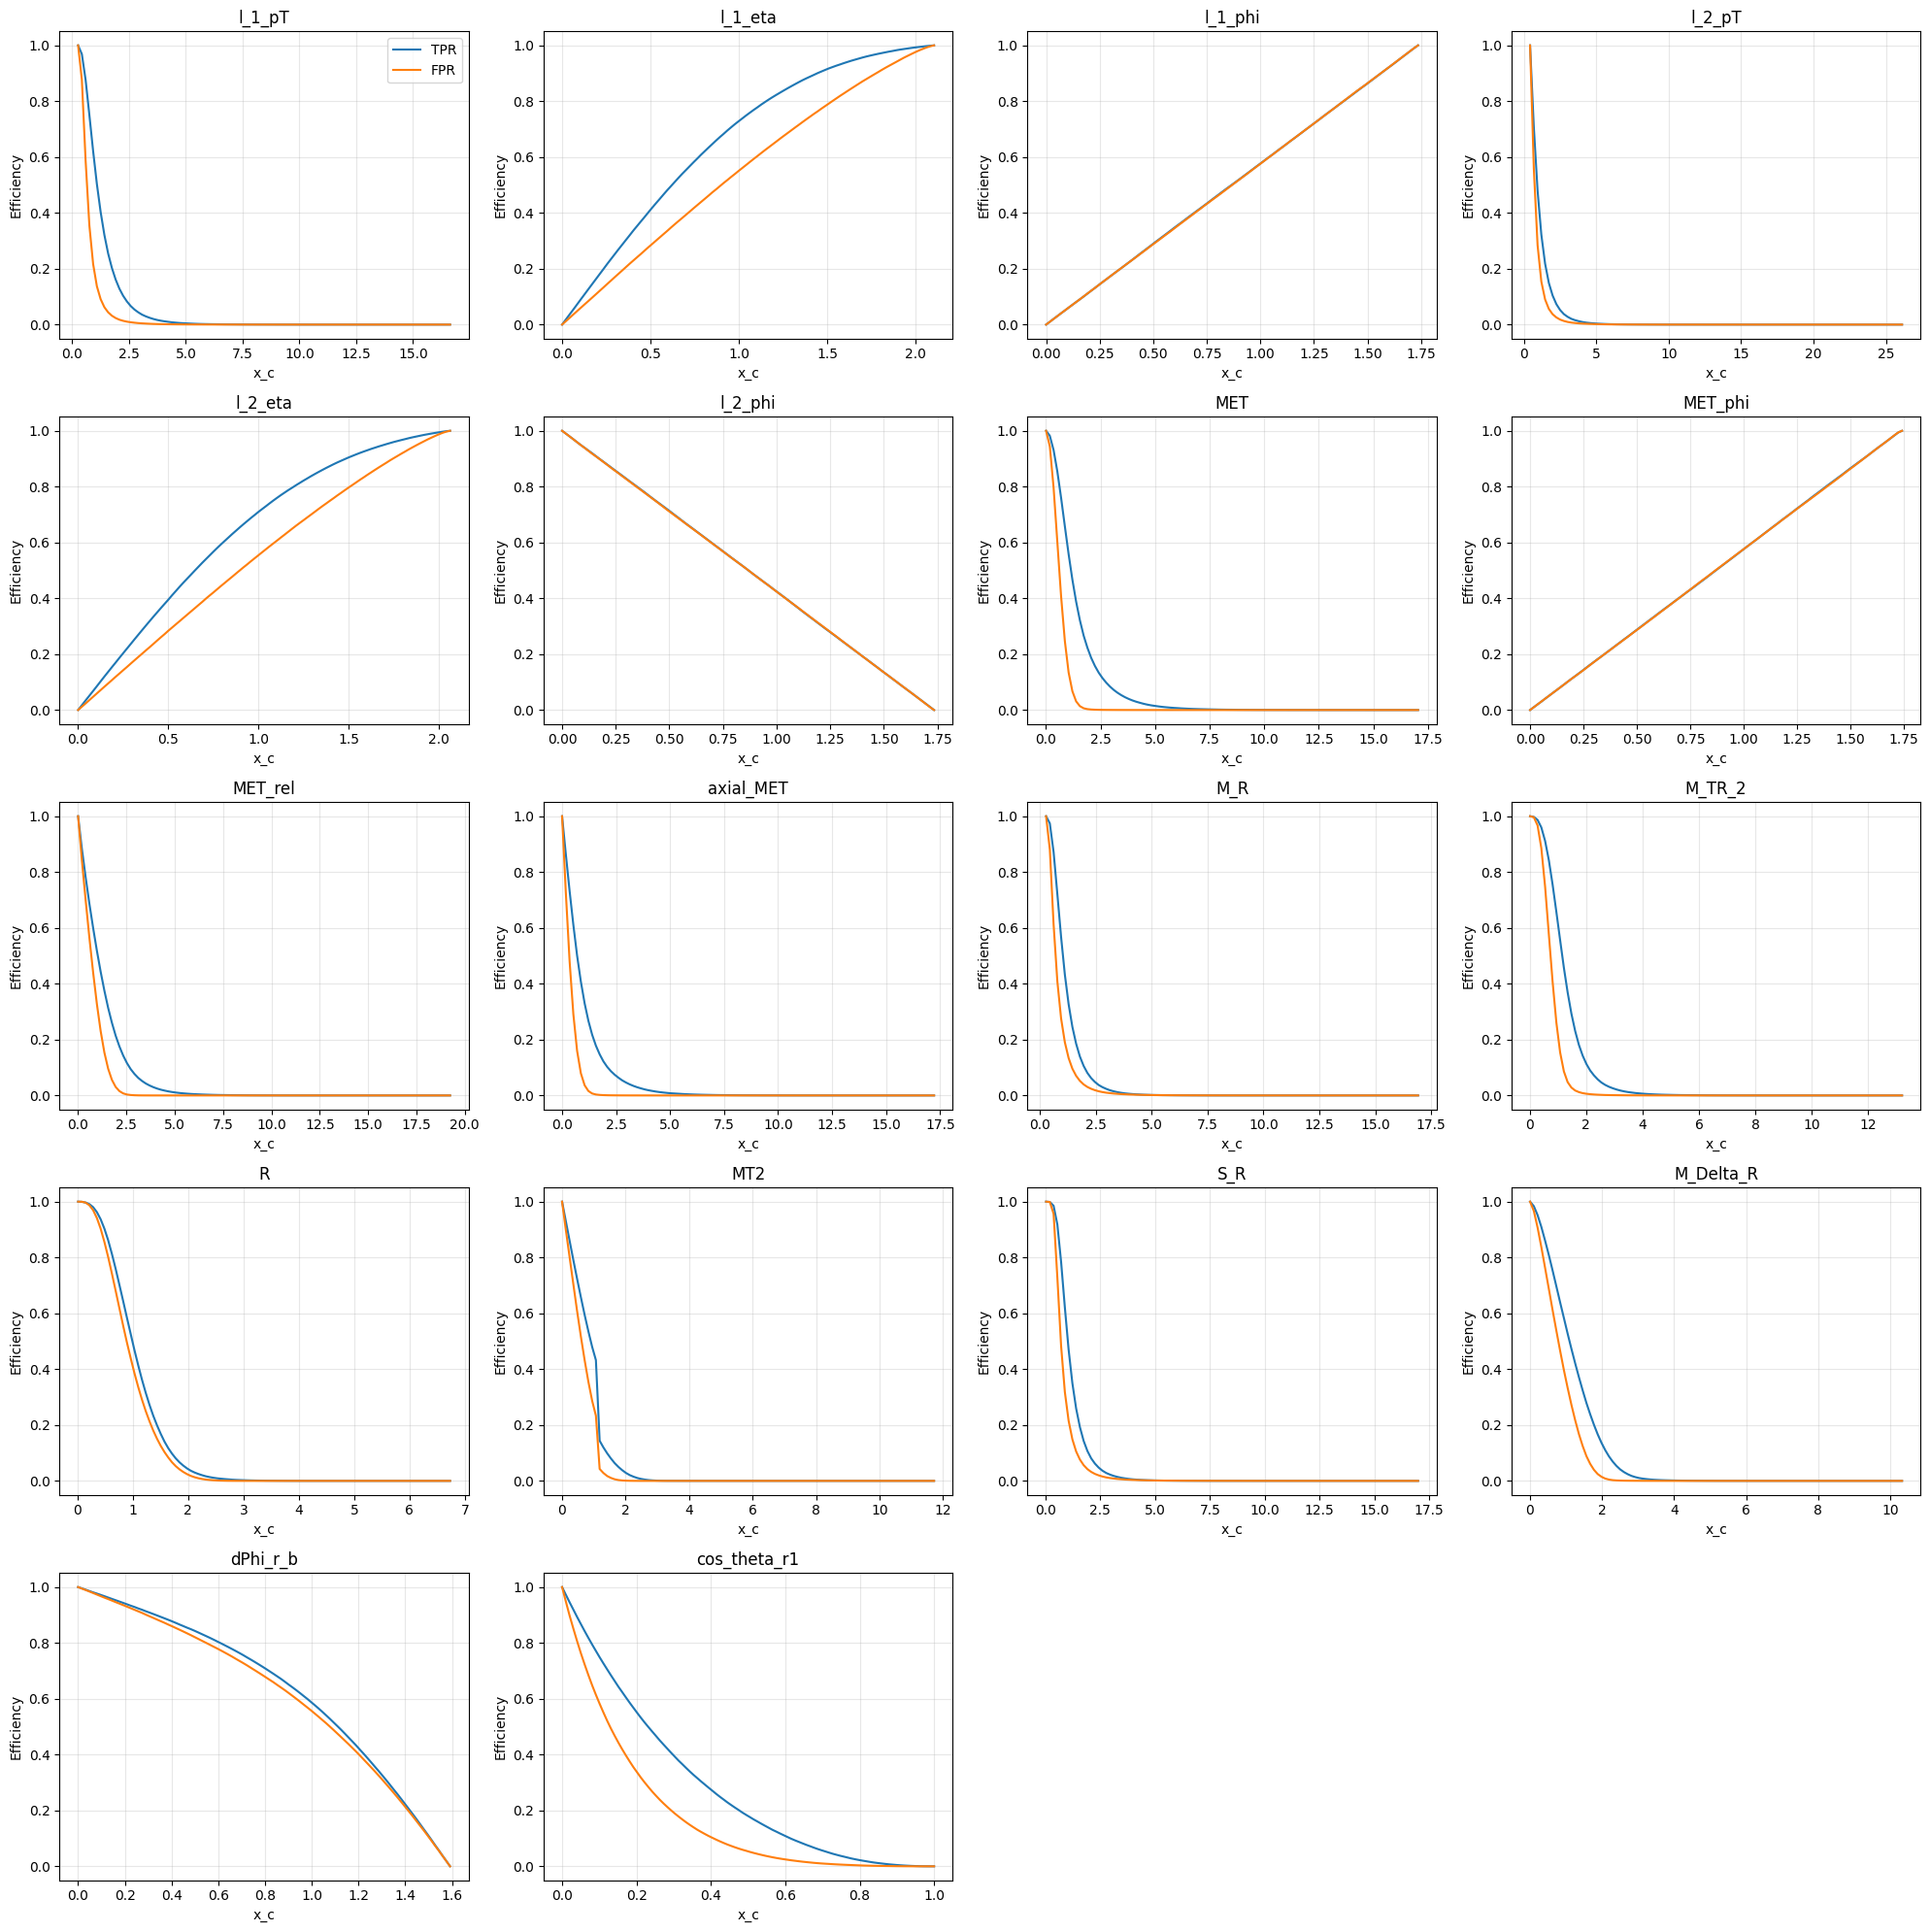

In [46]:
# Plotting TPR and FPR curves for all observables
n_vars = len(all_observables)
n_cols = 4
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(all_observables):
    
    # Getting the preferred cut strategy from part a
    strategy = best_strategy_dict[var]
    
    # Computing TPR and FPR curves
    x_scan, tpr_list, fpr_list = get_tpr_fpr_curves(df, var, strategy, n_points=100)
    
    # Plotting both curves on the same axes
    axes[i].plot(x_scan, tpr_list, label="TPR")
    axes[i].plot(x_scan, fpr_list, label="FPR")
    
    # Labeling the subplot
    axes[i].set_title(var)
    axes[i].set_xlabel("x_c")
    axes[i].set_ylabel("Efficiency")
    axes[i].grid(alpha=0.3)
    
    # Showing legend only once
    if i == 0:
        axes[i].legend()

# Hiding any unused subplots
for j in range(n_vars, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


For each observable, I used the selection strategy chosen in Exercise 5.1. Then I scanned over cut values x_c and computed the True Positive Rate (signal efficiency) and False Positive Rate (background efficiency). I plotted both as functions of x_c for each observable so I could see how well each cut keeps signal while rejecting background.

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

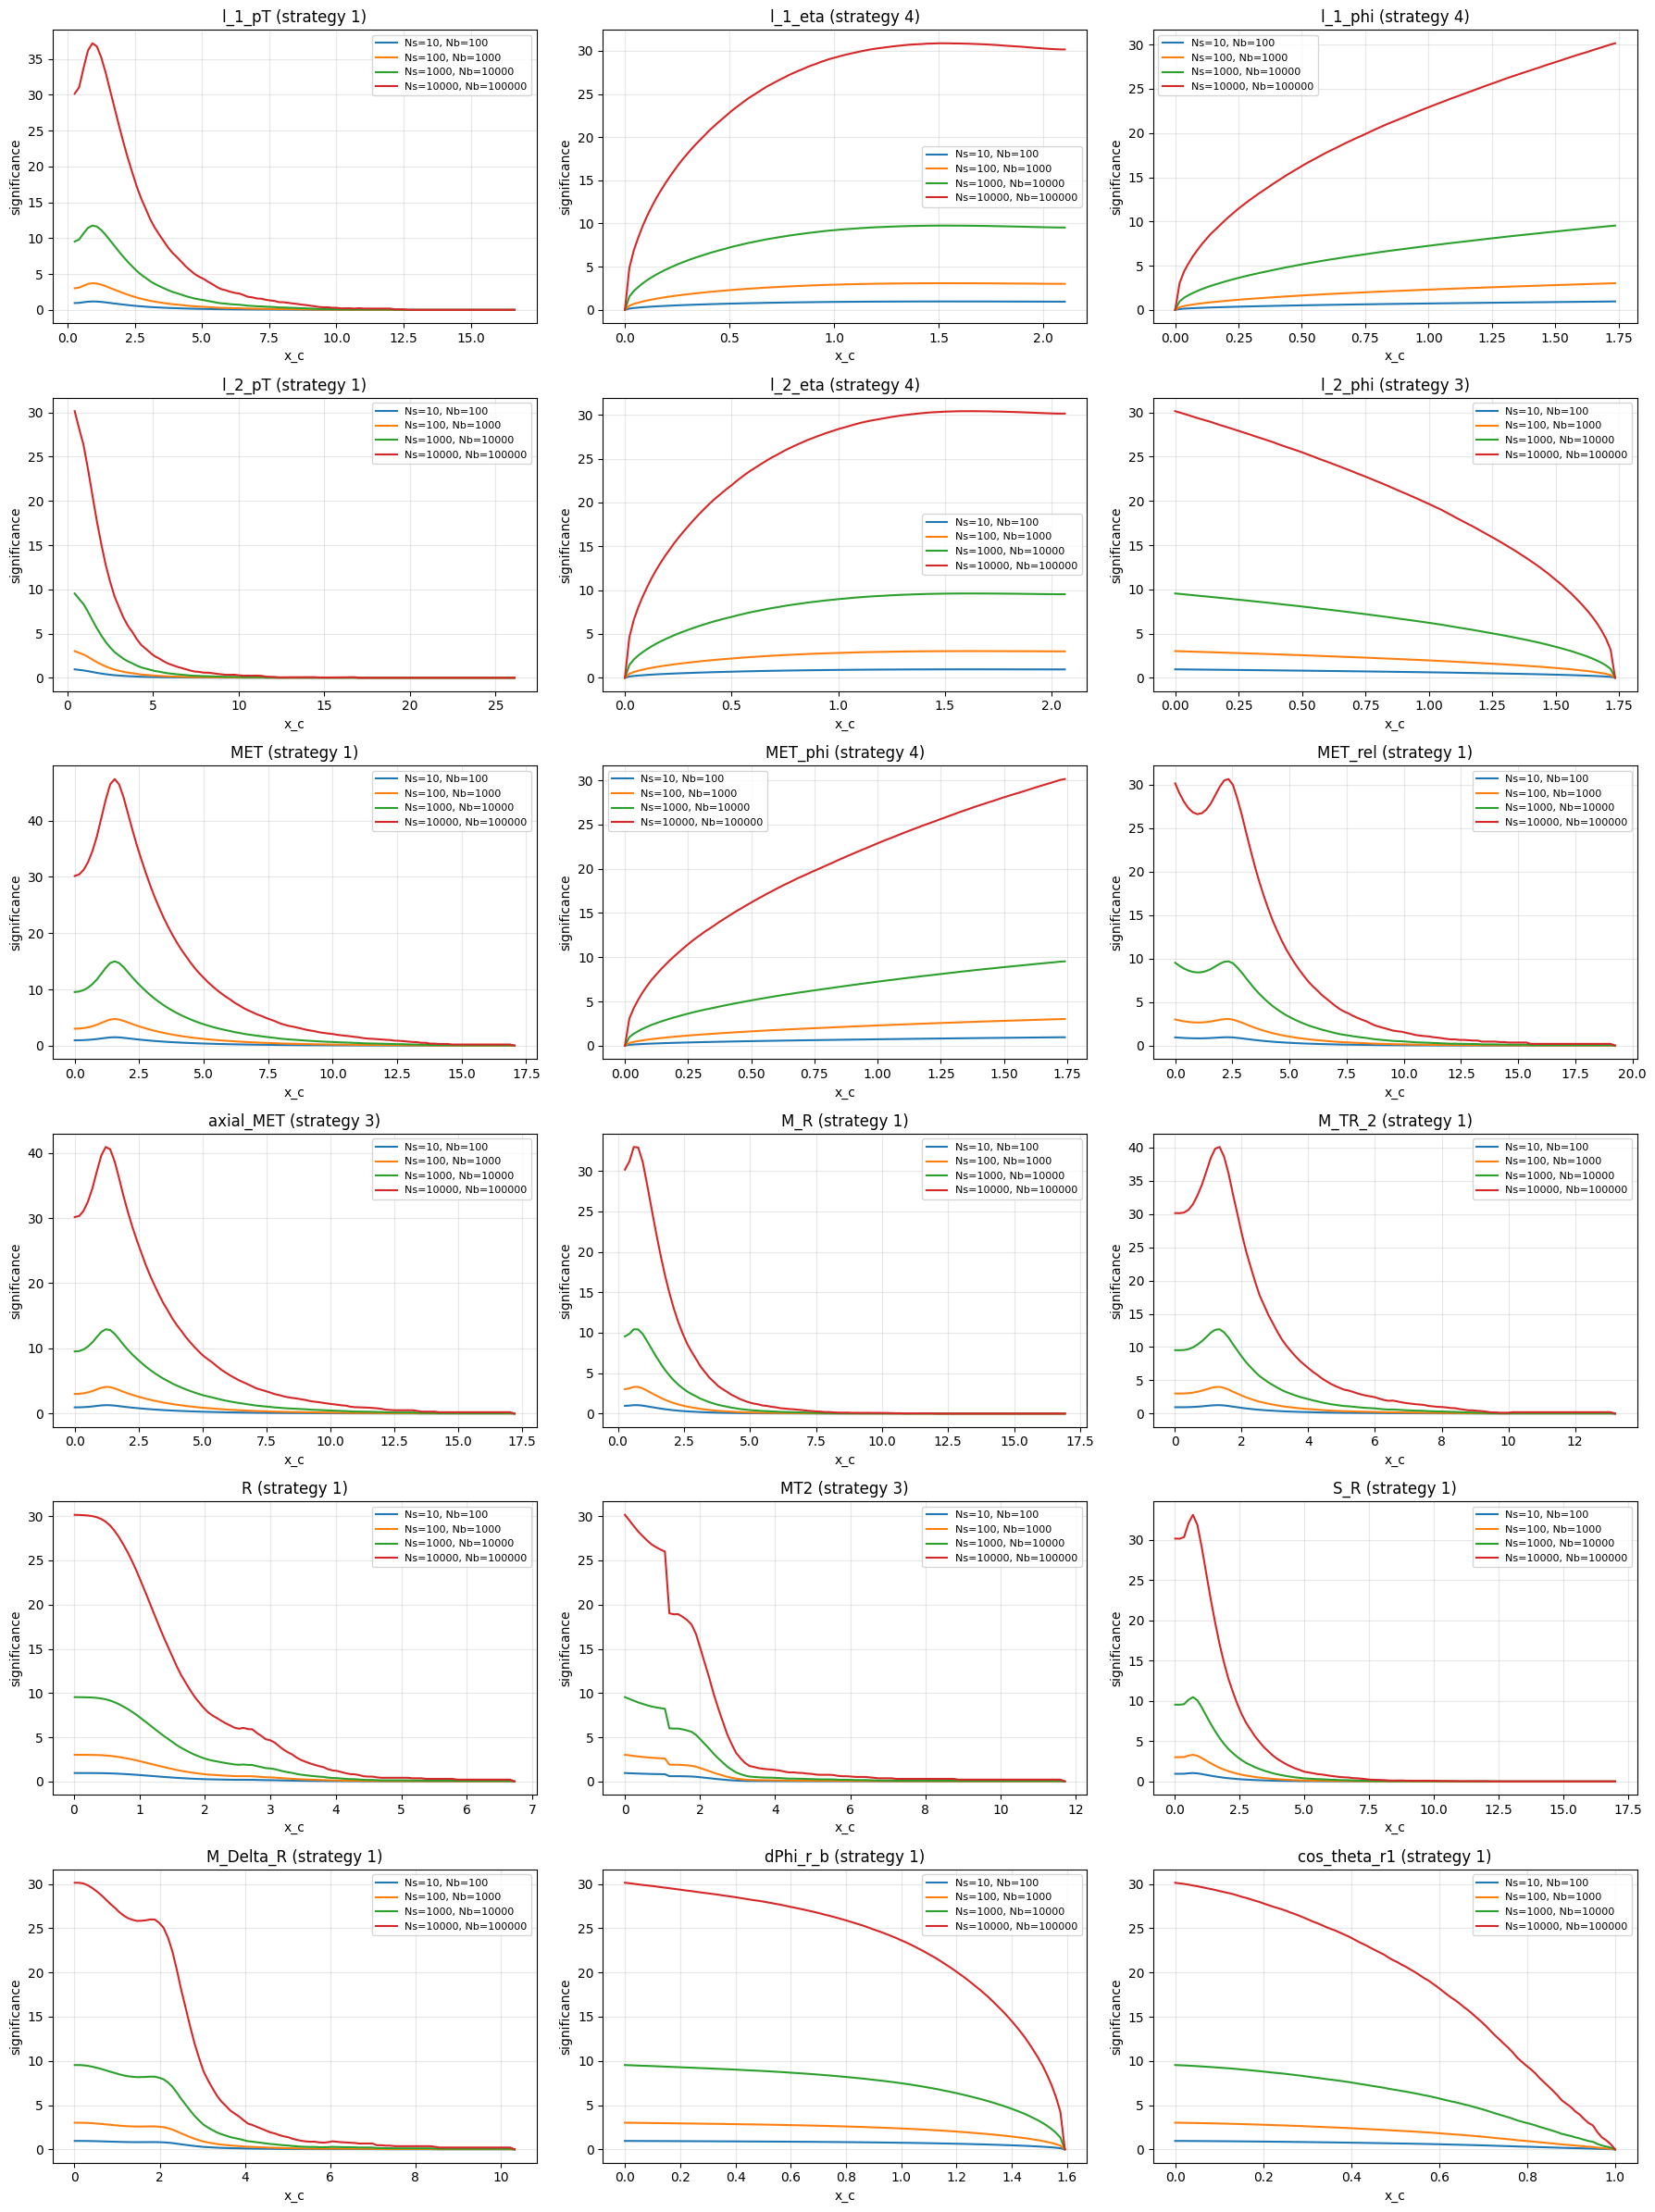

In [47]:
# Exercise 5.3
# Plotting the significance as a function of x_c for each observable

def get_significance_curve(df, var, strategy, N_S, N_B, n_points=100):
    
    # Reusing the TPR and FPR scan from part 5.2
    x_scan, tpr_list, fpr_list = get_tpr_fpr_curves(df, var, strategy, n_points=n_points)
    
    # Storing significance values across the cut scan
    significance_list = []
    
    for eps_s, eps_b in zip(tpr_list, fpr_list):
        
        # Computing expected surviving signal and background counts
        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B
        
        # Computing significance while avoiding division by zero
        if N_S_prime + N_B_prime > 0:
            sigma = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
        else:
            sigma = 0
        
        significance_list.append(sigma)
    
    return x_scan, significance_list


# Defining the scenarios from the lab prompt
scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]


# Plotting significance curves for all observables
all_observables = VarNames[1:]

n_vars = len(all_observables)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, var in enumerate(all_observables):
    
    # Getting the preferred cut strategy from part a
    strategy = best_strategy_dict[var]
    
    # Drawing one curve for each event-count scenario
    for N_S, N_B in scenarios:
        x_scan, significance_list = get_significance_curve(df, var, strategy, N_S, N_B, n_points=100)
        axes[i].plot(x_scan, significance_list, label="Ns=" + str(N_S) + ", Nb=" + str(N_B))
    
    # Labeling each subplot
    axes[i].set_title(var + " (strategy " + str(strategy) + ")")
    axes[i].set_xlabel("x_c")
    axes[i].set_ylabel("significance")
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)


# Hiding any unused subplots
for j in range(n_vars, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [48]:
# Exercise 6.1
# Choosing 3 observables for each scenario from the significance scans
# Saving the variable name, strategy, cut value, and best significance

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

all_observables = VarNames[1:]

best_cut_info = dict()

for N_S, N_B in scenarios:
    
    scenario_results = []
    
    for var in all_observables:
        
        # Getting the preferred strategy from Exercise 5.1
        strategy = best_strategy_dict[var]
        
        # Computing the significance curve for this observable
        x_scan, significance_list = get_significance_curve(df, var, strategy, N_S, N_B, n_points=100)
        
        # Finding the cut value that gives the largest significance
        significance_array = np.array(significance_list)
        best_index = np.argmax(significance_array)
        best_x_c = x_scan[best_index]
        best_sigma = significance_array[best_index]
        
        # Saving the result for later comparison
        scenario_results.append((var, strategy, best_x_c, best_sigma))
    
    # Sorting observables by best significance
    scenario_results = sorted(scenario_results, key=lambda x: x[3], reverse=True)
    
    # Keeping the top 3 observables for this scenario
    best_cut_info[(N_S, N_B)] = scenario_results[:3]
    
    # Printing the chosen observables for this scenario
    print("Scenario:", (N_S, N_B))
    for var, strategy, best_x_c, best_sigma in best_cut_info[(N_S, N_B)]:
        print(var, "-> strategy", strategy, ", x_c =", round(best_x_c, 4), ", sigma =", round(best_sigma, 4))
    print()

Scenario: (10, 100)
MET -> strategy 1 , x_c = 1.5511 , sigma = 1.4981
axial_MET -> strategy 3 , x_c = 1.2177 , sigma = 1.2937
M_TR_2 -> strategy 1 , x_c = 1.3419 , sigma = 1.2678

Scenario: (100, 1000)
MET -> strategy 1 , x_c = 1.5511 , sigma = 4.7375
axial_MET -> strategy 3 , x_c = 1.2177 , sigma = 4.0909
M_TR_2 -> strategy 1 , x_c = 1.3419 , sigma = 4.0091

Scenario: (1000, 10000)
MET -> strategy 1 , x_c = 1.5511 , sigma = 14.9813
axial_MET -> strategy 3 , x_c = 1.2177 , sigma = 12.9367
M_TR_2 -> strategy 1 , x_c = 1.3419 , sigma = 12.6779

Scenario: (10000, 100000)
MET -> strategy 1 , x_c = 1.5511 , sigma = 47.3751
axial_MET -> strategy 3 , x_c = 1.2177 , sigma = 40.9094
M_TR_2 -> strategy 1 , x_c = 1.3419 , sigma = 40.0911



In [66]:
# Exercise 6.2
# Creating a cut-flow table by applying cuts successively
# Tabulating epsilon_S, epsilon_B, N_S', N_B', and sigma_S'

from tabulate import tabulate
from IPython.display import display, HTML

# Applying one cut to a dataframe
def apply_cut(df_in, var, strategy, x_c):
    
    # Using the same mu definition as earlier from the full signal sample
    mu = df[df["signal"] == 1][var].mean()
    
    # Applying the selection mask
    passed = pass_selection(df_in[var], x_c, strategy, mu=mu)
    
    return df_in[passed].copy()


# Making a cut-flow table for one scenario
def make_cutflow_table(df, cut_list, N_S, N_B):
    
    df_current = df.copy()
    
    # Counting total signal and background events in the full sample
    n_sig_total = len(df[df["signal"] == 1])
    n_bkg_total = len(df[df["signal"] == 0])
    
    rows = []
    
    # Recording the starting point before any cuts
    n_sig = len(df_current[df_current["signal"] == 1])
    n_bkg = len(df_current[df_current["signal"] == 0])
    
    eps_s = n_sig / float(n_sig_total)
    eps_b = n_bkg / float(n_bkg_total)
    
    N_S_prime = eps_s * N_S
    N_B_prime = eps_b * N_B
    
    if N_S_prime + N_B_prime > 0:
        sigma = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
    else:
        sigma = 0.0
    
    rows.append([
        "start", "-", "-",
        round(eps_s, 4), round(eps_b, 4),
        round(N_S_prime, 2), round(N_B_prime, 2),
        round(sigma, 4)
    ])
    
    # Applying each cut successively
    for var, strategy, x_c in cut_list:
        
        df_current = apply_cut(df_current, var, strategy, x_c)
        
        n_sig = len(df_current[df_current["signal"] == 1])
        n_bkg = len(df_current[df_current["signal"] == 0])
        
        eps_s = n_sig / float(n_sig_total)
        eps_b = n_bkg / float(n_bkg_total)
        
        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B
        
        if N_S_prime + N_B_prime > 0:
            sigma = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
        else:
            sigma = 0.0
        
        rows.append([
            var,
            strategy,
            round(x_c, 4),
            round(eps_s, 4),
            round(eps_b, 4),
            round(N_S_prime, 2),
            round(N_B_prime, 2),
            round(sigma, 4)
        ])
    
    display(HTML(tabulate(
        rows,
        headers=["Cut", "Strategy", "x_c", "eps_S", "eps_B", "N'_S", "N'_B", "Significance"],
        tablefmt="html"
    )))


# Calling the function for each scenario
for N_S, N_B in scenarios:
    print("Scenario:", (N_S, N_B))
    cut_list = [(v, s, xc) for v, s, xc, _ in best_cut_info[(N_S, N_B)]]
    make_cutflow_table(df, cut_list, N_S, N_B)

Scenario: (10, 100)


Cut,Strategy,x_c,eps_S,eps_B,N'_S,N'_B,Significance
start,-,-,1,1,10,100,0.9535
MET,1,1.5511,0.3215,0.0139,3.22,1.39,1.4981
axial_MET,3,1.2177,0.2323,0.0102,2.32,1.02,1.2703
M_TR_2,1,1.3419,0.1632,0.0081,1.63,0.81,1.0446


Scenario: (100, 1000)


Cut,Strategy,x_c,eps_S,eps_B,N'_S,N'_B,Significance
start,-,-,1,1,100,1000,3.0151
MET,1,1.5511,0.3215,0.0139,32.15,13.91,4.7375
axial_MET,3,1.2177,0.2323,0.0102,23.23,10.21,4.0171
M_TR_2,1,1.3419,0.1632,0.0081,16.32,8.1,3.3034


Scenario: (1000, 10000)


Cut,Strategy,x_c,eps_S,eps_B,N'_S,N'_B,Significance
start,-,-,1,1,1000,10000,9.5346
MET,1,1.5511,0.3215,0.0139,321.51,139.06,14.9813
axial_MET,3,1.2177,0.2323,0.0102,232.29,102.08,12.7033
M_TR_2,1,1.3419,0.1632,0.0081,163.24,80.96,10.4461


Scenario: (10000, 100000)


Cut,Strategy,x_c,eps_S,eps_B,N'_S,N'_B,Significance
start,-,-,1,1,10000,100000,30.1511
MET,1,1.5511,0.3215,0.0139,3215.12,1390.56,47.3751
axial_MET,3,1.2177,0.2323,0.0102,2322.93,1020.85,40.1714
M_TR_2,1,1.3419,0.1632,0.0081,1632.4,809.59,33.0335


In [ ]:
# Exercise 6.3
# Studying effect of correlated variables and cut order

# Helper: computing significance

def compute_significance(eps_s, eps_b, N_S, N_B):
    N_S_prime = eps_s * N_S
    N_B_prime = eps_b * N_B
    if N_S_prime + N_B_prime > 0:
        return N_S_prime / np.sqrt(N_S_prime + N_B_prime)
    else:
        return 0.0


# Helper: finding most correlated pair from a list of variables

def get_most_correlated_pair(df, variables):
    X = df[variables].to_numpy()
    corr = np.corrcoef(X, rowvar=False)
    
    corr_abs = np.abs(corr.copy())
    np.fill_diagonal(corr_abs, 0.0)
    
    idx = np.argmax(corr_abs)
    i, j = np.unravel_index(idx, corr_abs.shape)
    
    return variables[i], variables[j]


# Helper: applying a cut using fixed mu from full signal sample

def apply_cut(df_in, var, strategy, x_c):
    mu = df[df["signal"] == 1][var].mean()
    mask = pass_selection(np.array(df_in[var]), x_c, strategy, mu=mu)
    return df_in[mask].copy()


# Helper: finding best cut for a variable on a given dataset

def get_best_cut(df_in, var, strategy, N_S, N_B, n_points=100):
    
    x_sig = np.array(df_in[df_in["signal"] == 1][var])
    x_bkg = np.array(df_in[df_in["signal"] == 0][var])
    x_all = np.array(df_in[var])
    
    mu = df[df["signal"] == 1][var].mean()
    x_scan = get_scan_values(x_all, strategy, n_points=n_points, mu=mu)
    
    best_sigma = -np.inf
    best_x_c = None
    best_eps_s = None
    best_eps_b = None
    
    for x_c in x_scan:
        eps_s = efficiency(x_sig, x_c, strategy, mu=mu)
        eps_b = efficiency(x_bkg, x_c, strategy, mu=mu)
        sigma = compute_significance(eps_s, eps_b, N_S, N_B)
        
        if sigma > best_sigma:
            best_sigma = sigma
            best_x_c = x_c
            best_eps_s = eps_s
            best_eps_b = eps_b
    
    return best_x_c, best_eps_s, best_eps_b, best_sigma


# Running comparison for each scenario
for N_S, N_B in scenarios:
    
    print("\nScenario:", (N_S, N_B))
    
    # Using variables selected in 6.1
    selected_vars = [v for v, _, _, _ in best_cut_info[(N_S, N_B)]]
    
    # Finding most correlated pair
    var1, var2 = get_most_correlated_pair(df, selected_vars)
    strategy1 = best_strategy_dict[var1]
    strategy2 = best_strategy_dict[var2]
    
    print("Testing pair:", var1, "and", var2)
    
    # Order 1: var1 -> var2
    x_c1, eps_s1, eps_b1, _ = get_best_cut(df, var1, strategy1, N_S, N_B)
    df_after1 = apply_cut(df, var1, strategy1, x_c1)
    
    N_S_after1 = eps_s1 * N_S
    N_B_after1 = eps_b1 * N_B
    
    x_c2, eps_s2_local, eps_b2_local, _ = get_best_cut(df_after1, var2, strategy2, N_S_after1, N_B_after1)
    
    eps_s_total_1 = eps_s1 * eps_s2_local
    eps_b_total_1 = eps_b1 * eps_b2_local
    sigma_total_1 = compute_significance(eps_s_total_1, eps_b_total_1, N_S, N_B)
    
    print("Order 1:", var1, "->", var2, ", sigma =", round(sigma_total_1, 4))
    
    # Order 2: var2 -> var1
    x_c2, eps_s2, eps_b2, _ = get_best_cut(df, var2, strategy2, N_S, N_B)
    df_after2 = apply_cut(df, var2, strategy2, x_c2)
    
    N_S_after2 = eps_s2 * N_S
    N_B_after2 = eps_b2 * N_B
    
    x_c1, eps_s1_local, eps_b1_local, _ = get_best_cut(df_after2, var1, strategy1, N_S_after2, N_B_after2)
    
    eps_s_total_2 = eps_s2 * eps_s1_local
    eps_b_total_2 = eps_b2 * eps_b1_local
    sigma_total_2 = compute_significance(eps_s_total_2, eps_b_total_2, N_S, N_B)
    
    print("Order 2:", var2, "->", var1, ", sigma =", round(sigma_total_2, 4))
    
    # Comparing
    if sigma_total_1 > sigma_total_2:
        print("Better order:", var1, "->", var2)
    elif sigma_total_2 > sigma_total_1:
        print("Better order:", var2, "->", var1)
    else:
        print("Both orders give similar significance")

From the correlation study, the strongest issue should appear for the most correlated pair among the selected observables,
because the single-variable optimization assumes the cuts act independently when they do not.
After applying one cut first and then re-optimizing the second variable, the best x_c changes.
Reversing the order can also change the final significance, showing that correlations matterand that the best cut order is not always symmetric.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

/var/folders/26/zfzpvncj5rs8mhythzxcf5b80000gn/T/ipykernel_6153/1540580135.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


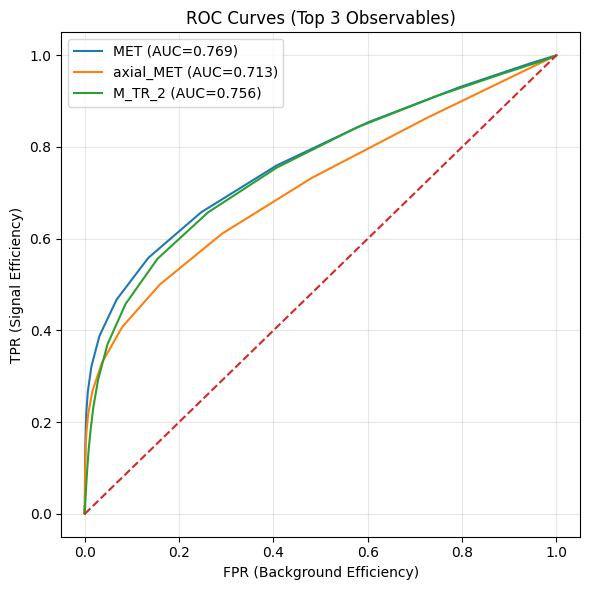

In [50]:
# Exercise 7.1
# Plotting ROC curves using the same TPR/FPR logic from Exercise 5

plt.figure(figsize=(6, 6))

# Using top 3 observables from Exercise 6.1
top_vars = [var for var, _, _, _ in best_cut_info[scenarios[0]]]

for var in top_vars:
    
    # Using previously chosen strategy
    strategy = best_strategy_dict[var]
    
    # Getting TPR and FPR from earlier function
    x_scan, tpr_list, fpr_list = get_tpr_fpr_curves(df, var, strategy, n_points=100)
    
    # Converting to arrays
    tpr = np.array(tpr_list)
    fpr = np.array(fpr_list)
    
    # Sorting for proper ROC curve and AUC
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]
    
    # Computing AUC using trapezoidal rule
    auc = np.trapz(tpr, fpr)
    
    # Plotting ROC curve
    plt.plot(fpr, tpr, label=var + " (AUC=" + str(round(auc, 3)) + ")")

# Plotting random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("FPR (Background Efficiency)")
plt.ylabel("TPR (Signal Efficiency)")
plt.title("ROC Curves (Top 3 Observables)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

In [55]:
# Exercise 7.2
# Creating a reusable function to plot ROC curves for any set of observables

def plot_roc_curves(df, observables, strategy_dict, n_points=100, title="ROC Curves"):
    
    # Creating figure
    plt.figure(figsize=(6, 6))
    
    for var in observables:
        
        # Using strategy determined earlier
        strategy = strategy_dict[var]
        
        # Computing TPR and FPR from cut scan
        x_scan, tpr_list, fpr_list = get_tpr_fpr_curves(df, var, strategy, n_points=n_points)
        
        # Converting to numpy arrays
        tpr = np.array(tpr_list)
        fpr = np.array(fpr_list)
        
        # Sorting values for correct ROC curve and AUC
        order = np.argsort(fpr)
        fpr = fpr[order]
        tpr = tpr[order]
        
        # Computing AUC
        auc = np.trapz(tpr, fpr)
        
        # Plotting curve
        plt.plot(fpr, tpr, label=var + " (AUC=" + str(round(auc, 3)) + ")")
    
    # Plotting random classifier line
    plt.plot([0, 1], [0, 1], linestyle="--")
    
    # Labeling
    plt.xlabel("FPR (Background Efficiency)")
    plt.ylabel("TPR (Signal Efficiency)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/26/zfzpvncj5rs8mhythzxcf5b80000gn/T/ipykernel_6153/3962944501.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


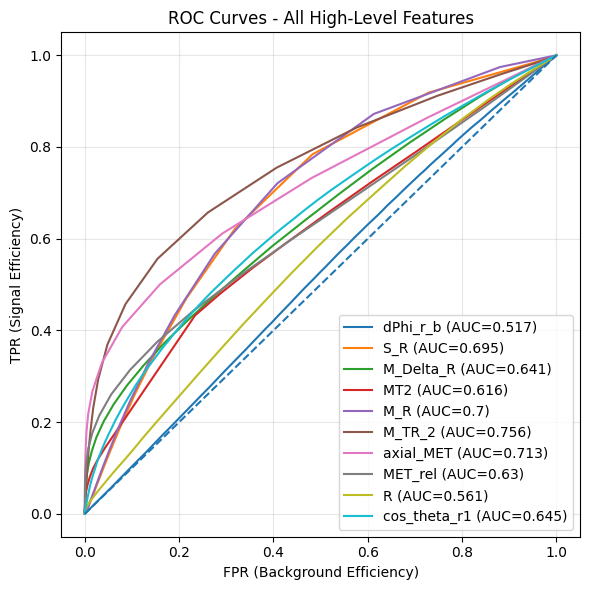

In [53]:
# Example usage (testing on high-level features)
plot_roc_curves(df, FeatureNames, best_strategy_dict, title="ROC Curves - All High-Level Features")

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

/var/folders/26/zfzpvncj5rs8mhythzxcf5b80000gn/T/ipykernel_6153/1643916038.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


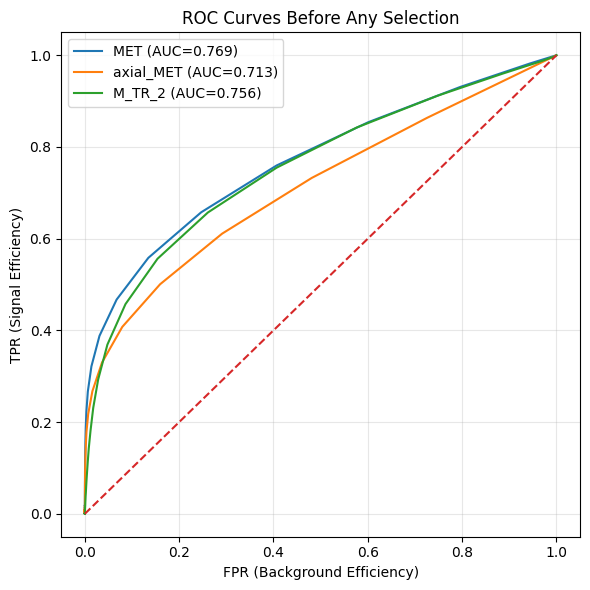

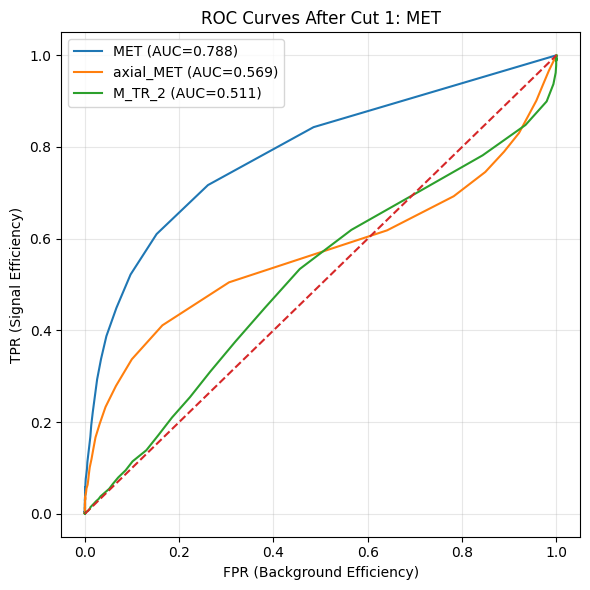

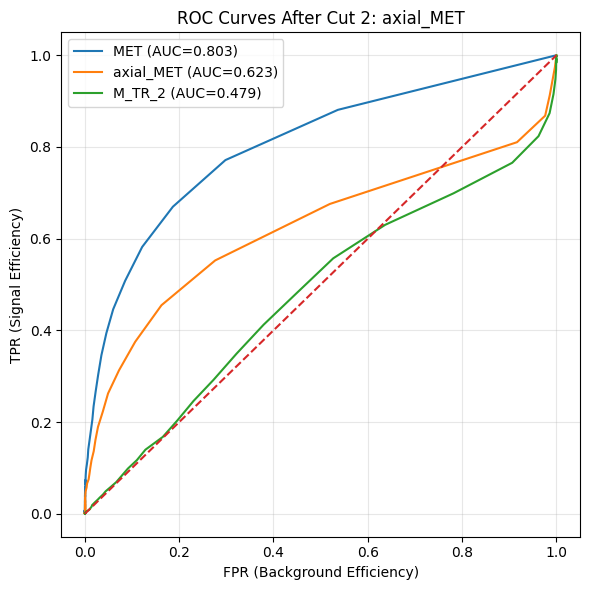

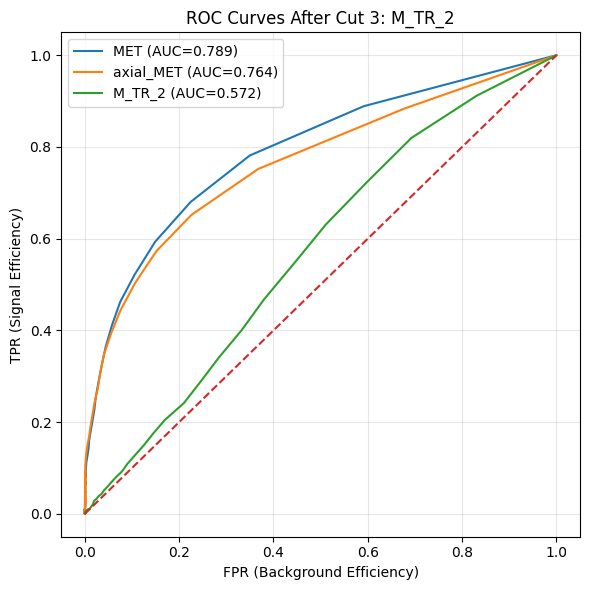

In [57]:
# Exercise 7.3
# Comparing ROC curves after successive selections
# Reusing the ROC function from Exercise 7.2 on the reduced sample after each cut


# Making a local cut helper so this cell is self-contained
def apply_cut_for_roc(df_in, var, strategy, x_c):
    
    # Using the signal mean from the full sample for strategies 3 and 4
    mu = df[df["signal"] == 1][var].mean()
    
    # Applying the same selection logic used earlier in the lab
    passed = pass_selection(np.array(df_in[var]), x_c, strategy, mu=mu)
    
    return df_in[passed].copy()


# Applying cuts one by one and reusing the part b function after each step
# Keeping the same observable list each time so the ROC comparison is consistent
N_S, N_B = scenarios[0]
cut_list = [(var, strategy, x_c) for var, strategy, x_c, _ in best_cut_info[(N_S, N_B)]]

# Using the top 3 observables from Exercise 6.1 for this scenario
roc_observables = [var for var, _, _, _ in best_cut_info[(N_S, N_B)]]

# Plotting ROC curves before any cuts
plot_roc_curves(df, roc_observables, best_strategy_dict,
                title="ROC Curves Before Any Selection")

# Applying each cut successively and plotting ROC curves after each selection
df_current = df.copy()

for i, (var, strategy, x_c) in enumerate(cut_list):
    
    # Applying the next cut
    df_current = apply_cut_for_roc(df_current, var, strategy, x_c)
    
    # Plotting ROC curves on the reduced sample using the same function from part b
    plot_roc_curves(df_current, roc_observables, best_strategy_dict,
                    title="ROC Curves After Cut " + str(i + 1) + ": " + var)


### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.

Order 1: MET then axial_MET


/var/folders/26/zfzpvncj5rs8mhythzxcf5b80000gn/T/ipykernel_6153/1643916038.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


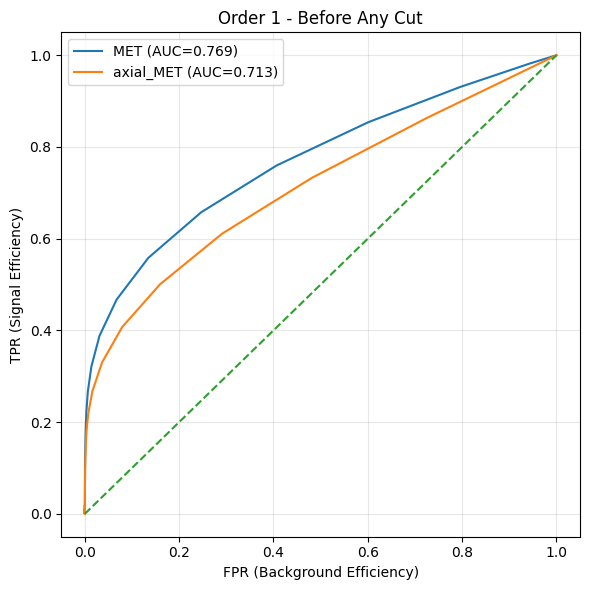

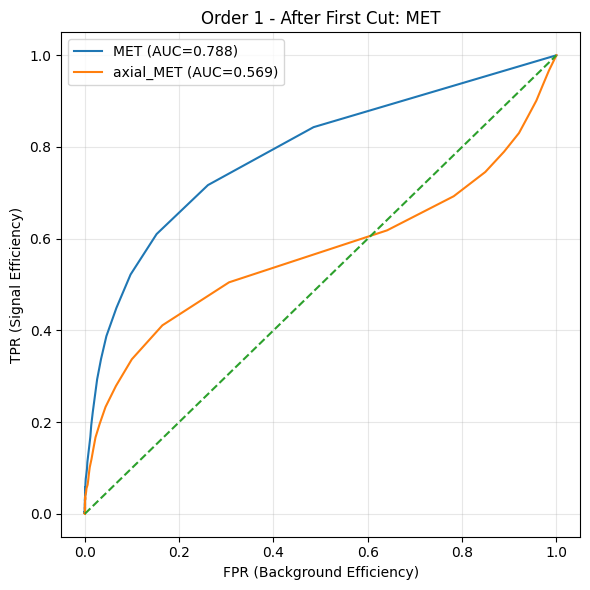

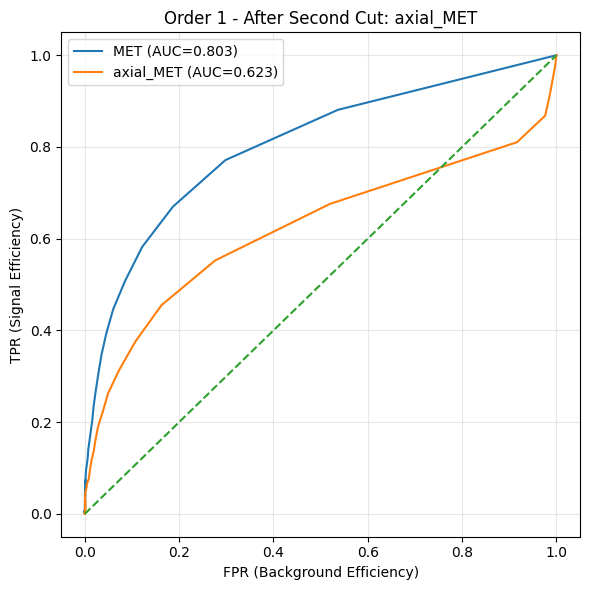

Order 2: axial_MET then MET


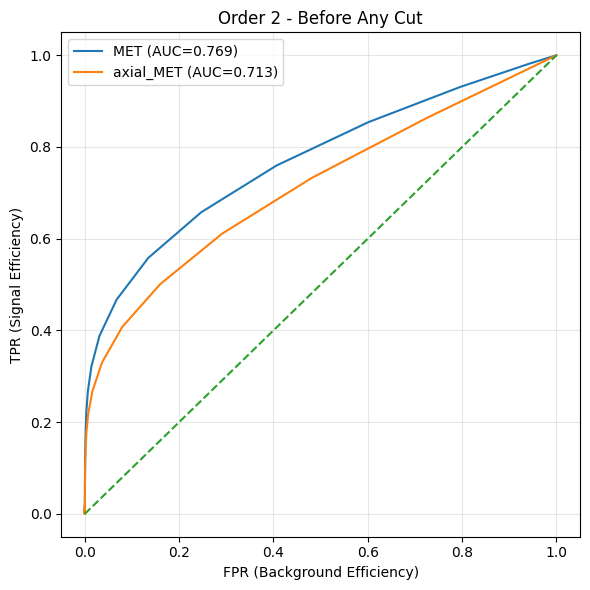

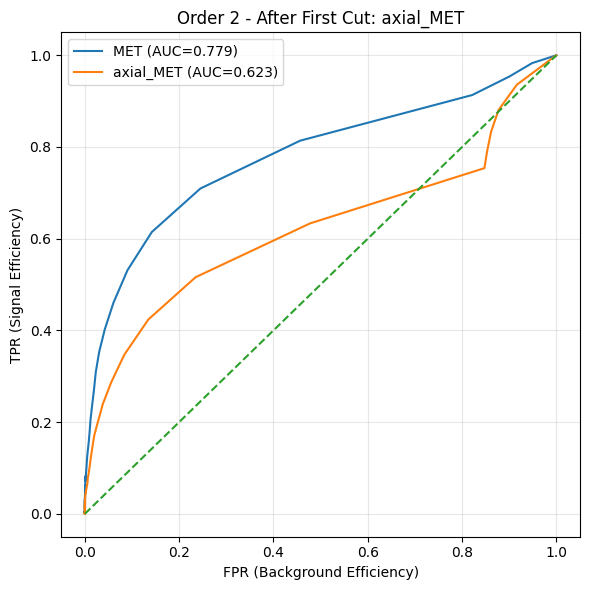

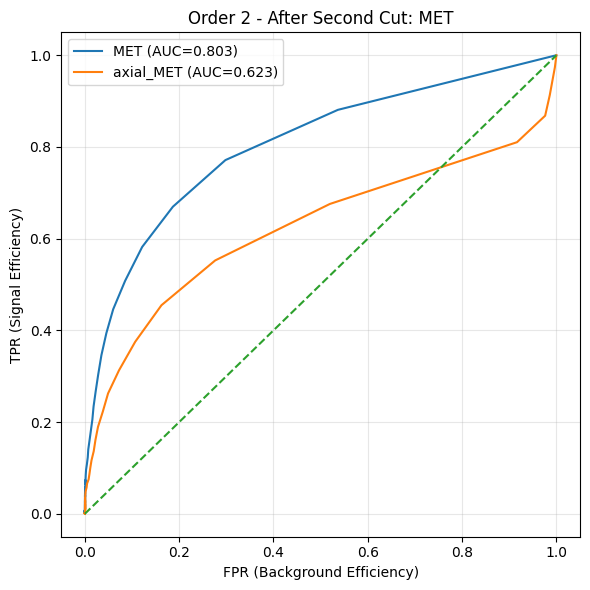

Changing the cut order can change the ROC curves after each step because the first cut changes the sample seen by the second cut. If the observables are correlated, the second cut may add less new separation depending on which cut was applied first.


In [59]:
# Exercise 7.4
# Demonstrating the effect of changing the order of successive selections
# Reusing the ROC plotting function from Exercise 7.2

# Making a local cut helper so this cell is self-contained
def apply_cut_for_roc(df_in, var, strategy, x_c):
    
    # Using the signal mean from the full sample for strategies 3 and 4
    mu = df[df["signal"] == 1][var].mean()
    
    # Applying the same selection logic used earlier in the lab
    passed = pass_selection(np.array(df_in[var]), x_c, strategy, mu=mu)
    
    return df_in[passed].copy()


# Choosing an example pair from the first scenario
# Using the first two selected observables from Exercise 6.1
N_S, N_B = scenarios[0]
selected_cuts = [(var, strategy, x_c) for var, strategy, x_c, _ in best_cut_info[(N_S, N_B)]]

first_cut = selected_cuts[0]
second_cut = selected_cuts[1]

# Keeping the same observables in the ROC comparison
roc_observables = [first_cut[0], second_cut[0]]


# Order 1: first_cut then second_cut
print("Order 1:", first_cut[0], "then", second_cut[0])

df_order1 = df.copy()
plot_roc_curves(df_order1, roc_observables, best_strategy_dict,
                title="Order 1 - Before Any Cut")

df_order1 = apply_cut_for_roc(df_order1, first_cut[0], first_cut[1], first_cut[2])
plot_roc_curves(df_order1, roc_observables, best_strategy_dict,
                title="Order 1 - After First Cut: " + first_cut[0])

df_order1 = apply_cut_for_roc(df_order1, second_cut[0], second_cut[1], second_cut[2])
plot_roc_curves(df_order1, roc_observables, best_strategy_dict,
                title="Order 1 - After Second Cut: " + second_cut[0])


# Order 2: second_cut then first_cut
print("Order 2:", second_cut[0], "then", first_cut[0])

df_order2 = df.copy()
plot_roc_curves(df_order2, roc_observables, best_strategy_dict,
                title="Order 2 - Before Any Cut")

df_order2 = apply_cut_for_roc(df_order2, second_cut[0], second_cut[1], second_cut[2])
plot_roc_curves(df_order2, roc_observables, best_strategy_dict,
                title="Order 2 - After First Cut: " + second_cut[0])

df_order2 = apply_cut_for_roc(df_order2, first_cut[0], first_cut[1], first_cut[2])
plot_roc_curves(df_order2, roc_observables, best_strategy_dict,
                title="Order 2 - After Second Cut: " + first_cut[0])



print("Changing the cut order can change the ROC curves after each step because the first cut changes the sample seen by the second cut. If the observables are correlated, the second cut may add less new separation depending on which cut was applied first.")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

In [62]:
# Exercise 8.1
# Computing the between-class and within-class scatter matrices
# Using signal and background as the two classes

import numpy as np

# Using all observables except the class label
obs_cols = VarNames[1:]

# Separating signal and background samples
if "df_sig" not in globals():
    df_sig = df[df["signal"] == 1].copy()
if "df_bkg" not in globals():
    df_bkg = df[df["signal"] == 0].copy()

# Extracting selected observables as numpy arrays
X_sig = df_sig[obs_cols].to_numpy()
X_bkg = df_bkg[obs_cols].to_numpy()

# Computing the mean vectors for each class
m_sig = np.mean(X_sig, axis=0)
m_bkg = np.mean(X_bkg, axis=0)

# Computing between-class scatter matrix
# Using the outer product of the difference in class means
diff = (m_bkg - m_sig).reshape(-1, 1)
S_B = diff @ diff.T

# Computing within-class scatter matrix
# Centering each class around its own mean
X_sig_centered = X_sig - m_sig
X_bkg_centered = X_bkg - m_bkg

# Summing the scatter contributions from both classes
S_W = X_sig_centered.T @ X_sig_centered + X_bkg_centered.T @ X_bkg_centered

# Printing shapes to check the result
print("Signal mean vector shape:", m_sig.shape)
print("Background mean vector shape:", m_bkg.shape)
print("S_B shape:", S_B.shape)
print("S_W shape:", S_W.shape)

# Showing the matrices
print("\nBetween-class scatter matrix S_B:")
print(S_B)

print("\nWithin-class scatter matrix S_W:")
print(S_W)


Signal mean vector shape: (18,)
Background mean vector shape: (18,)
S_B shape: (18, 18)
S_W shape: (18, 18)

Between-class scatter matrix S_B:
[[ 2.87970231e-01  4.58922304e-04  4.67467434e-04  1.38148662e-01
   1.54068049e-03  3.66095560e-04  4.13461344e-01 -6.36618070e-04
   2.71136238e-01  8.54657090e-02  1.82331687e-01  2.66557653e-01
   5.53227373e-02  7.37824064e-02  1.74241790e-01  1.84116478e-01
   1.54056891e-02  5.66281031e-02]
 [ 4.58922304e-04  7.31359210e-07  7.44977113e-07  2.20159917e-04
   2.45529768e-06  5.83426339e-07  6.58910580e-04 -1.01454317e-06
   4.32094896e-04  1.36201995e-04  2.90571971e-04  4.24798257e-04
   8.81648006e-05  1.17582959e-04  2.77679548e-04  2.93416294e-04
   2.45511986e-05  9.02450903e-05]
 [ 4.67467434e-04  7.44977113e-07  7.58848582e-07  2.24259293e-04
   2.50101531e-06  5.94289733e-07  6.71179491e-04 -1.03343396e-06
   4.40140500e-04  1.38738075e-04  2.95982420e-04  4.32707998e-04
   8.98064286e-05  1.19772353e-04  2.82849940e-04  2.98879704

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

w shape: (18,)


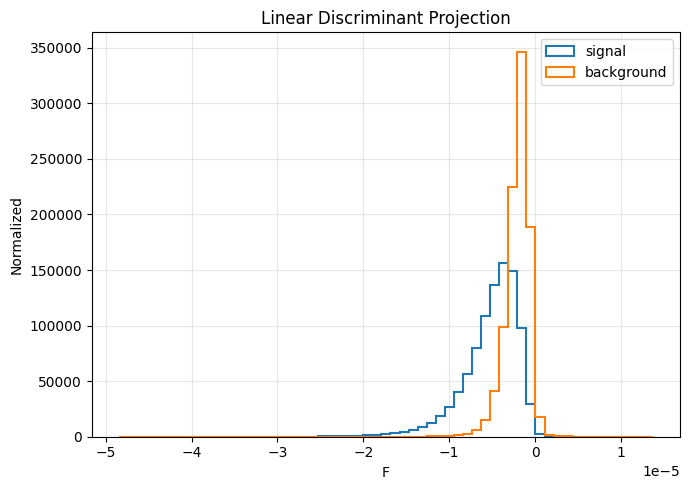

In [63]:
# Exercise 8.2
# Computing the linear coefficients w = S_W^(-1) (m_2 - m_1)
# Comparing the projected distributions for signal and background

import numpy as np
import matplotlib.pyplot as plt

# Using the same class means and scatter matrix from Exercise 8.1
mean_diff = (m_bkg - m_sig)

# Computing the linear coefficient vector
w = np.linalg.inv(S_W) @ mean_diff

# Projecting each event onto the linear discriminant direction
F_sig = X_sig @ w
F_bkg = X_bkg @ w

# Printing shape to check the result
print("w shape:", w.shape)

# Plotting the projected distributions for the two classes
plt.figure(figsize=(7, 5))

# Computing common bin edges for fair comparison
xmin = min(F_sig.min(), F_bkg.min())
xmax = max(F_sig.max(), F_bkg.max())
bins = np.linspace(xmin, xmax, 60)

# Plotting normalized histograms
plt.hist(F_sig, bins=bins, histtype="step", density=True,
         linewidth=1.5, label="signal")
plt.hist(F_bkg, bins=bins, histtype="step", density=True,
         linewidth=1.5, label="background")

plt.xlabel("F")
plt.ylabel("Normalized")
plt.title("Linear Discriminant Projection")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Exercise 8.3

Draw the ROC curve for $F_n$. 

/var/folders/26/zfzpvncj5rs8mhythzxcf5b80000gn/T/ipykernel_6153/162408088.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(TPR, FPR)


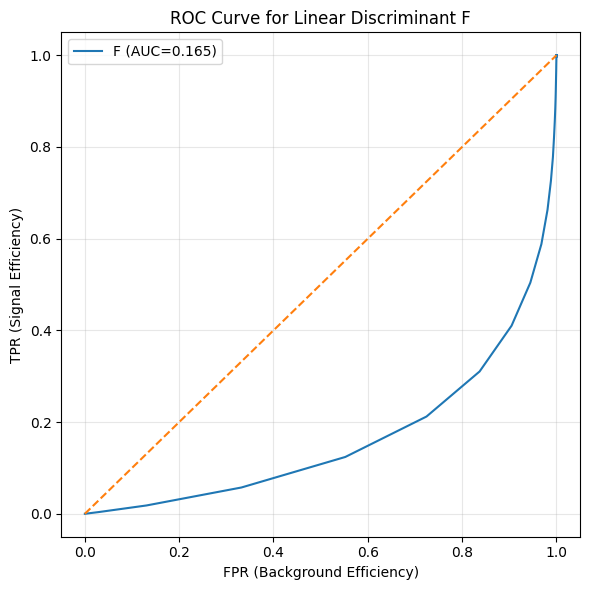

In [64]:
# Exercise 8.3
# Drawing ROC curve for the linear discriminant F

# Using projected values from Exercise 8.2
# F_sig and F_bkg already computed

# Combining into one dataset-like structure
F_all = np.concatenate([F_sig, F_bkg])
labels = np.concatenate([np.ones(len(F_sig)), np.zeros(len(F_bkg))])

# Scanning thresholds over F
thresholds = np.linspace(F_all.min(), F_all.max(), 100)

TPR = []
FPR = []

# Computing TPR and FPR for each threshold
for t in thresholds:
    
    # Applying threshold cut: F > t
    sig_pass = np.sum(F_sig > t)
    bkg_pass = np.sum(F_bkg > t)
    
    # Computing rates
    tpr = sig_pass / float(len(F_sig))
    fpr = bkg_pass / float(len(F_bkg))
    
    TPR.append(tpr)
    FPR.append(fpr)

TPR = np.array(TPR)
FPR = np.array(FPR)

# Sorting for proper ROC curve
order = np.argsort(FPR)
FPR = FPR[order]
TPR = TPR[order]

# Computing AUC
auc = np.trapz(TPR, FPR)

# Plotting ROC curve
plt.figure(figsize=(6,6))
plt.plot(FPR, TPR, label="F (AUC=" + str(round(auc, 3)) + ")")

# Diagonal reference line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("FPR (Background Efficiency)")
plt.ylabel("TPR (Signal Efficiency)")
plt.title("ROC Curve for Linear Discriminant F")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [65]:
# Exercise 8.4
# Finding the maximal significance from the linear discriminant F
# Using the same event-count scenarios from Exercise 5

# Reusing projected values from Exercise 8.2
# F_sig and F_bkg already computed

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

# Building threshold scan over the discriminant output
F_all = np.concatenate([F_sig, F_bkg])
thresholds = np.linspace(F_all.min(), F_all.max(), 200)

for N_S, N_B in scenarios:
    
    best_sigma = -np.inf
    best_threshold = None
    best_eps_s = None
    best_eps_b = None
    
    # Scanning threshold values
    for t in thresholds:
        
        # Computing signal and background efficiencies
        eps_s = np.sum(F_sig > t) / float(len(F_sig))
        eps_b = np.sum(F_bkg > t) / float(len(F_bkg))
        
        # Computing expected surviving counts
        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B
        
        # Computing significance
        if N_S_prime + N_B_prime > 0:
            sigma = N_S_prime / np.sqrt(N_S_prime + N_B_prime)
        else:
            sigma = 0
        
        # Updating best result
        if sigma > best_sigma:
            best_sigma = sigma
            best_threshold = t
            best_eps_s = eps_s
            best_eps_b = eps_b
    
    print("Scenario:", (N_S, N_B))
    print("Best threshold:", round(best_threshold, 4))
    print("epsilon_S:", round(best_eps_s, 4))
    print("epsilon_B:", round(best_eps_b, 4))
    print("Max significance:", round(best_sigma, 4))
    print()

Scenario: (10, 100)
Best threshold: -0.0
epsilon_S: 1.0
epsilon_B: 1.0
Max significance: 0.9535

Scenario: (100, 1000)
Best threshold: -0.0
epsilon_S: 1.0
epsilon_B: 1.0
Max significance: 3.0151

Scenario: (1000, 10000)
Best threshold: -0.0
epsilon_S: 1.0
epsilon_B: 1.0
Max significance: 9.5346

Scenario: (10000, 100000)
Best threshold: -0.0
epsilon_S: 1.0
epsilon_B: 1.0
Max significance: 30.151

